# Introduction to Pandas: Plotting

## Preliminaries and Setup

We start this notebook by typing a "magic" command that allows iPython notebooks to display plots directly in the browser.

In [1]:
!sudo apt-get install -y -qq  libgeos-dev libproj-dev proj-data proj-bin libgdal-dev libspatialindex-dev
!sudo pip install -U shapely rtree pygeos

!sudo pip install geopandas descartes


debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 4.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package libspatialindex6:amd64.
(Reading database ... 126675 files and directories currently installed.)
Preparing to unpack .../libspatialindex6_1.9.3-2_amd64.deb ...
Unpacking libspatialindex6:amd64 (1.9.3-2) ...
Selecting previously unselected package libspatialindex-c6:amd64.
Preparing to unpack .../libspatialindex-c6_1.9.3-2_amd64.deb ...
Unpacking libspatialindex-c6:amd64 (1.9.3-2) ...
Selecting previously unselected package proj-bin.
Preparing to unpack .../proj-bin_9.3.1-1~jammy0_amd64.deb ...
Unpacking pr

In [2]:
# Render our plots inline
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

In [3]:
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd

In [4]:
#sns.set_style("whitegrid")
#sns.set(rc={'figure.figsize': (20, 20)})
#matplotlib.style.use(['seaborn-talk', 'seaborn-ticks'])

## Using plotting for data analysis

We finished our earlier notebook by analyzing the [NYPD Vehicle Collissions](https://data.cityofnewyork.us/Public-Safety/NYPD-Motor-Vehicle-Collisions/h9gi-nx95/data) data set. We continue our analysis now, focusing on plotting.


Just in case you do not have the dataset, you can run the command below, to download the latest version:

In [5]:
# Takes 2-3 mins to download ~300Mb
!curl 'https://data.cityofnewyork.us/api/views/h9gi-nx95/rows.csv?accessType=DOWNLOAD' -o accidents.csv

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  444M    0  444M    0     0  3156k      0 --:--:--  0:02:24 --:--:-- 1966k


Now let's load the dataset.

In [6]:
import pandas as pd
df = pd.read_csv(
    "accidents.csv",
    parse_dates=True,
    infer_datetime_format=True,
    low_memory=False)

/tmp/ipython-input-1519619756.py:2: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df = pd.read_csv(


And check the datatypes to see if there is something that needs to be coverted.

In [7]:
df.dtypes

,0
CRASH DATE,object
CRASH TIME,object
BOROUGH,object
ZIP CODE,object
LATITUDE,float64
LONGITUDE,float64
LOCATION,object
ON STREET NAME,object
CROSS STREET NAME,object
OFF STREET NAME,object


In [8]:
df['DATETIME'] = df['CRASH DATE'].str.cat(df['CRASH TIME'], sep=' ')
df.DATETIME = pd.to_datetime(df.DATETIME, format="%m/%d/%Y %H:%M")

In [9]:
df['CRASH TIME'] = pd.to_datetime(df['CRASH TIME'], format="%H:%M")

In [10]:
df['CRASH DATE'] = pd.to_datetime(df['CRASH DATE'], format="%m/%d/%Y")

In [11]:
df['INJURY'] = (df['NUMBER OF PERSONS INJURED']>0)
df['DEATH'] = (df['NUMBER OF PERSONS KILLED']>0)

In [12]:
df.head(5)

,CRASH DATE,CRASH TIME,BOROUGH,ZIP CODE,LATITUDE,LONGITUDE,LOCATION,ON STREET NAME,CROSS STREET NAME,OFF STREET NAME,...,CONTRIBUTING FACTOR VEHICLE 5,COLLISION_ID,VEHICLE TYPE CODE 1,VEHICLE TYPE CODE 2,VEHICLE TYPE CODE 3,VEHICLE TYPE CODE 4,VEHICLE TYPE CODE 5,DATETIME,INJURY,DEATH
0,2021-09-11,1900-01-01 02:39:00,NaN,NaN,NaN,NaN,NaN,WHITESTONE EXPRESSWAY,20 AVENUE,NaN,...,NaN,4455765,Sedan,Sedan,NaN,NaN,NaN,2021-09-11 02:39:00,True,False
1,2022-03-26,1900-01-01 11:45:00,NaN,NaN,NaN,NaN,NaN,QUEENSBORO BRIDGE UPPER,NaN,NaN,...,NaN,4513547,Sedan,NaN,NaN,NaN,NaN,2022-03-26 11:45:00,True,False
2,2023-11-01,1900-01-01 01:29:00,BROOKLYN,11230,40.62179,-73.970024,"(40.62179, -73.970024)",OCEAN PARKWAY,AVENUE K,NaN,...,NaN,4675373,Moped,Sedan,Sedan,NaN,NaN,2023-11-01 01:29:00,True,False
3,2022-06-29,1900-01-01 06:55:00,NaN,NaN,NaN,NaN,NaN,THROGS NECK BRIDGE,NaN,NaN,...,NaN,4541903,Sedan,Pick-up Truck,NaN,NaN,NaN,2022-06-29 06:55:00,False,False
4,2022-09-21,1900-01-01 13:21:00,NaN,NaN,NaN,NaN,NaN,BROOKLYN BRIDGE,NaN,NaN,...,NaN,4566131,Station Wagon/Sport Utility Vehicle,NaN,NaN,NaN,NaN,2022-09-21 13:21:00,False,False


## Overplotting

Let us create a scatterplot of the accidents.

<Axes: xlabel='LONGITUDE', ylabel='LATITUDE'>

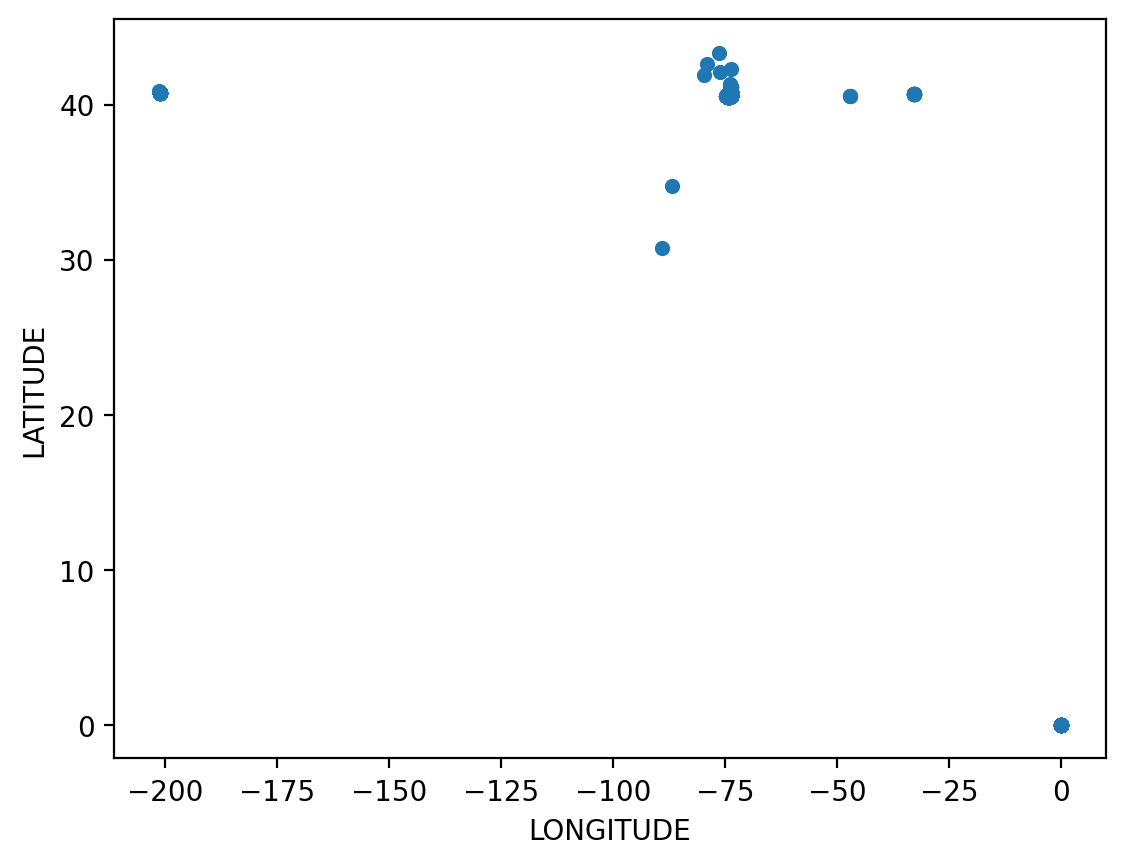

In [13]:
df.plot(kind='scatter', x='LONGITUDE', y='LATITUDE')

Unfortunately, there were cases in the dataset where longitude and latitude were incorrect. Therefore, we create a selection condition to keep only the entries that are valid. We often call such conditions as **masks**.

In [14]:
clean_mask = (df.LATITUDE > 40) & (df.LATITUDE < 41) & (df.LONGITUDE < -72) & (df.LONGITUDE > -74.5)
cleandf = df[clean_mask]

Now we created the new dataframe `cleandf` and we plot again:

<Axes: xlabel='LONGITUDE', ylabel='LATITUDE'>

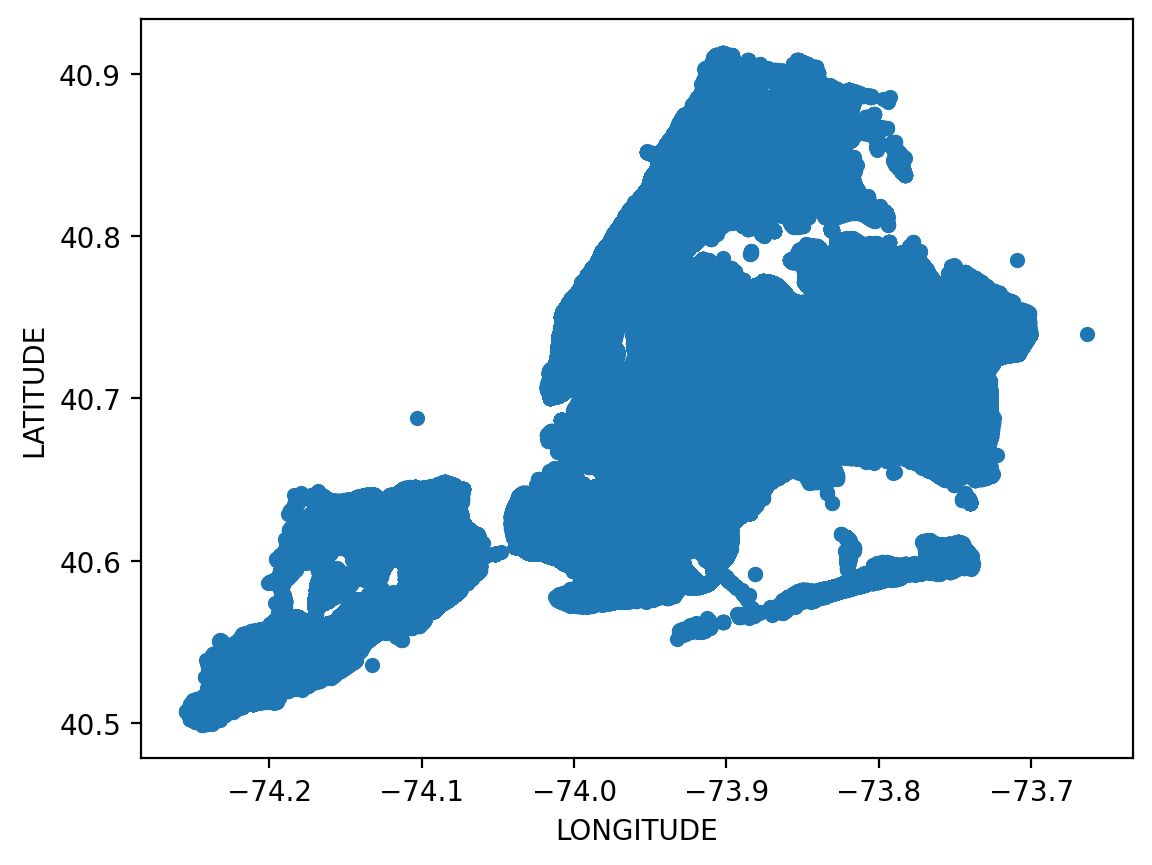

In [15]:
cleandf.plot(kind='scatter', x='LONGITUDE', y='LATITUDE')

We start seeing the shape of NYC now. Let's make the plot a bit bigger, using the `figsize = (20,15)` option, asking the size of the figure to have length 20 on the x axis and 15 on the y axis.

<Axes: xlabel='LONGITUDE', ylabel='LATITUDE'>

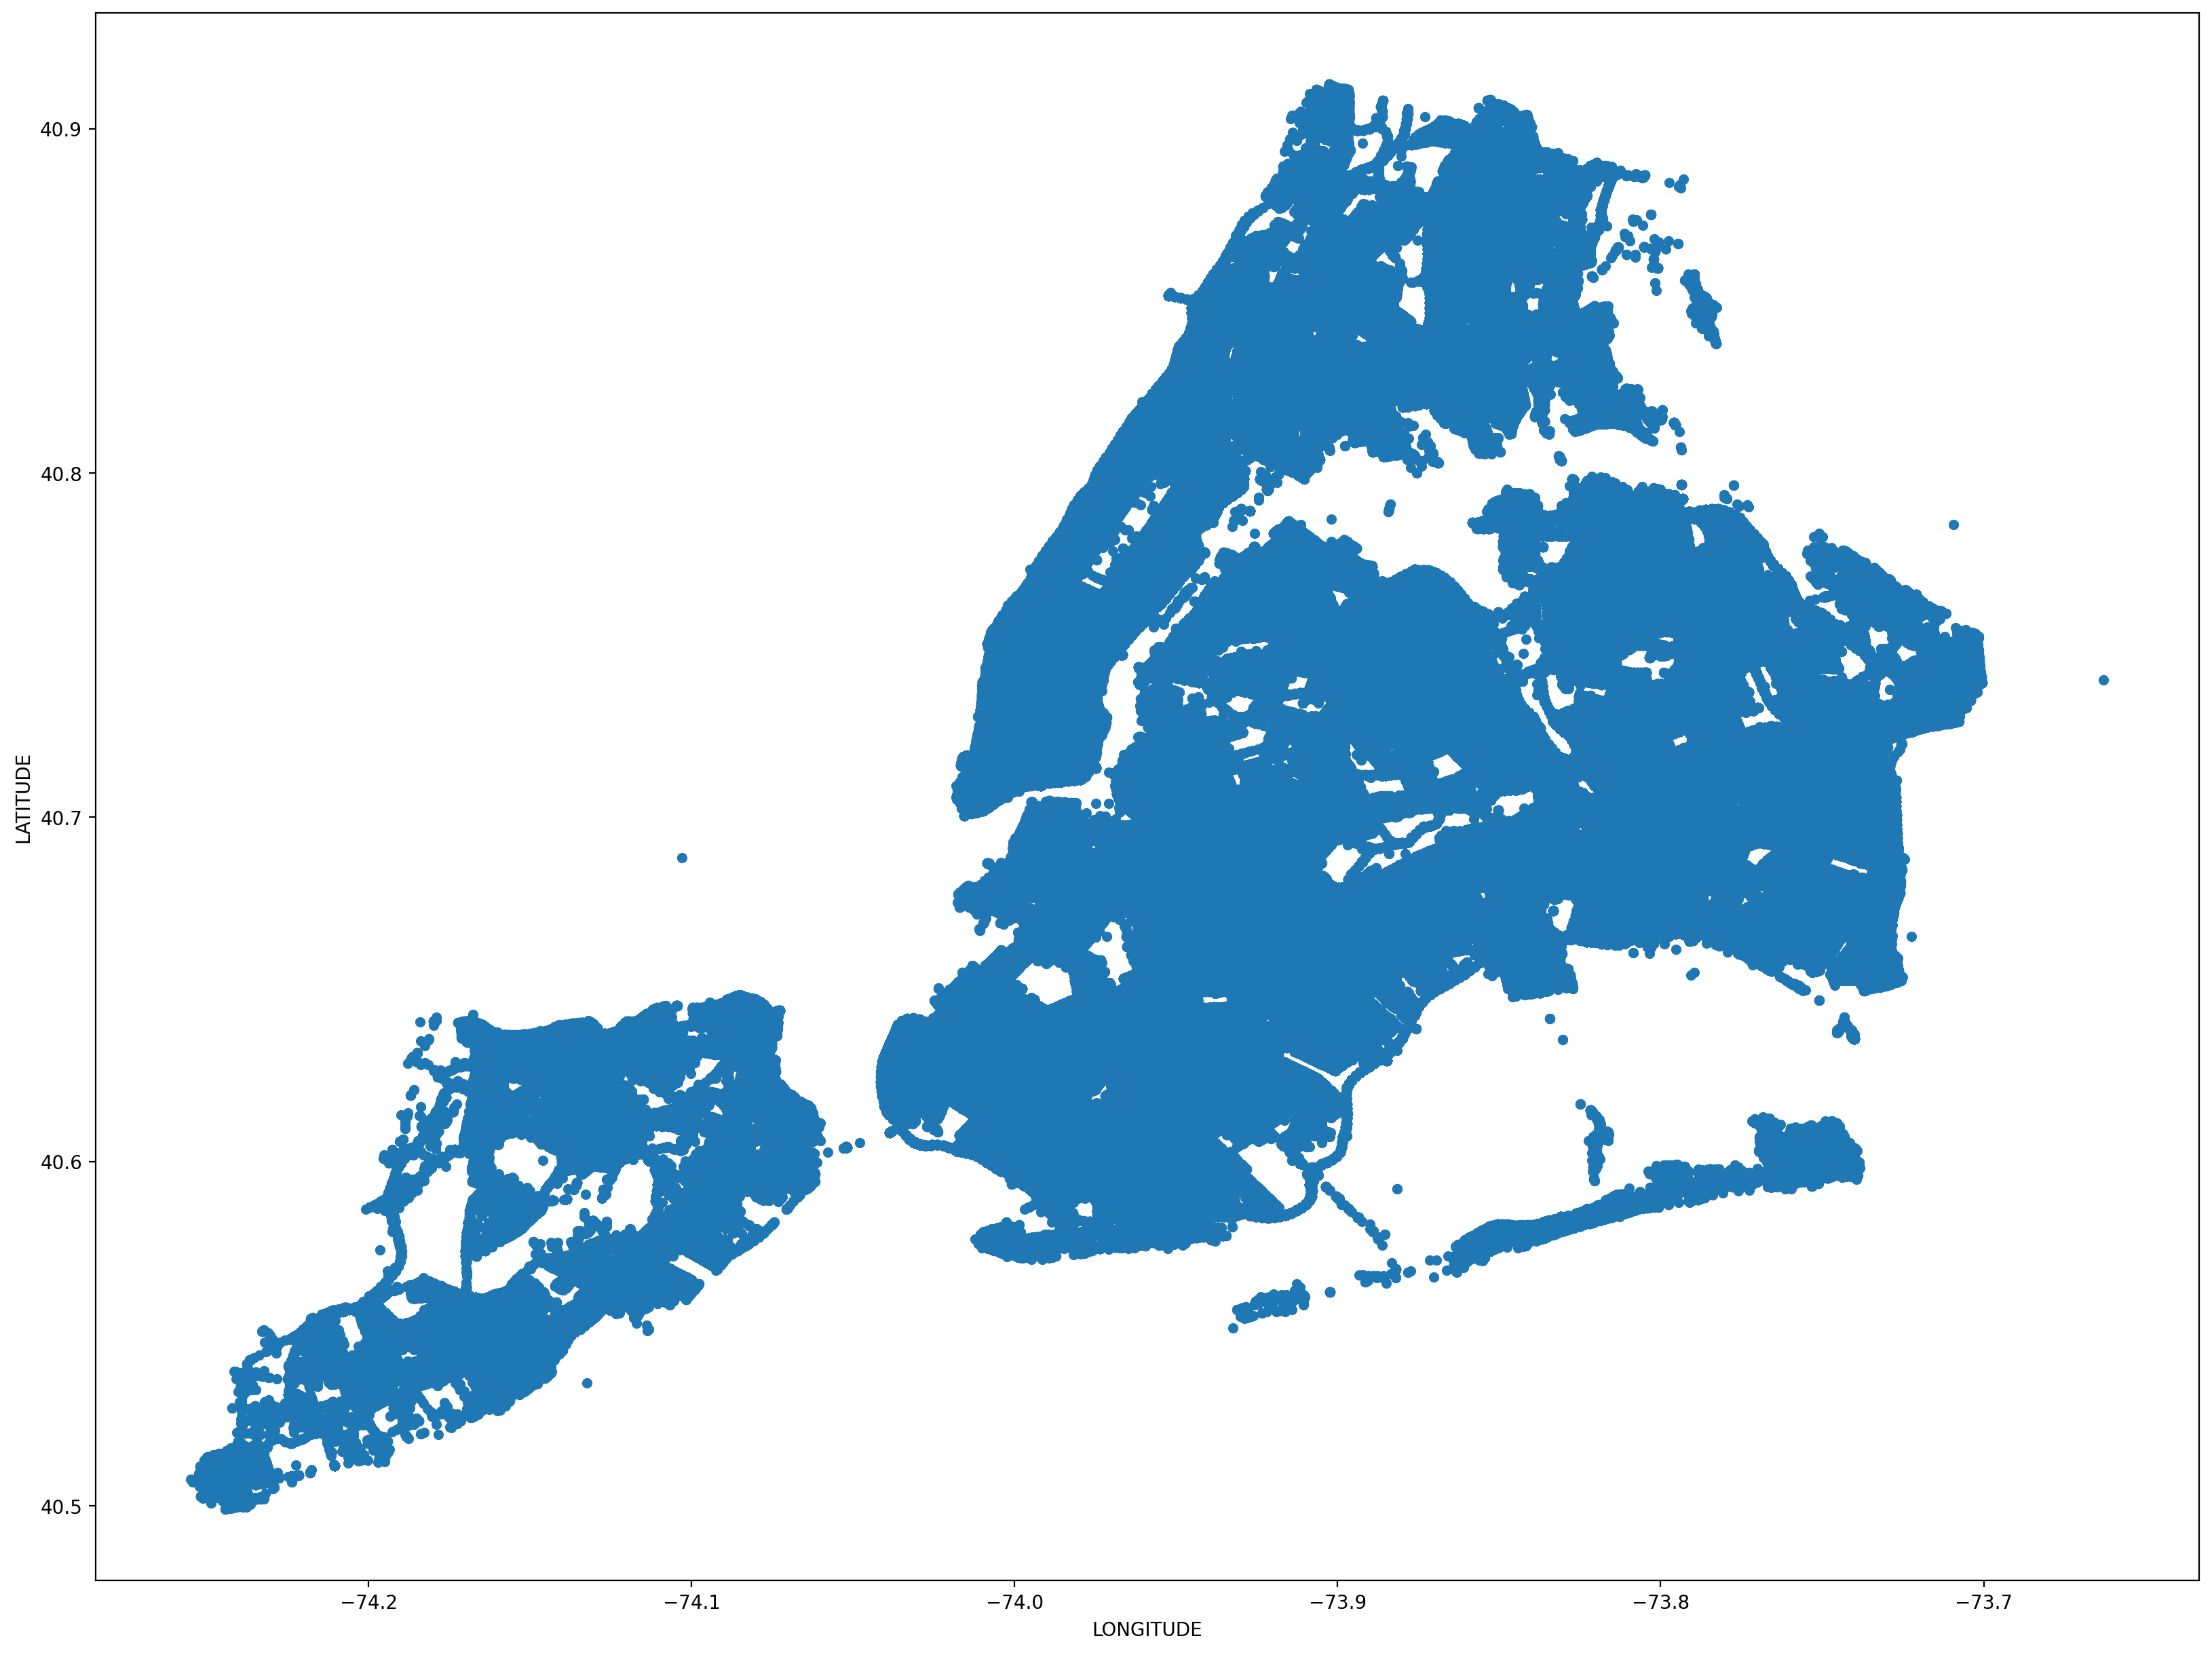

In [16]:
cleandf.plot(kind='scatter', x='LONGITUDE', y='LATITUDE', figsize=(20, 15))

## Addressing Overplotting


The picture above is showing us that accidents happen in all places in NYC, except maybe some areas of Staten Island. But we have so many data points (~1 million), that we cannot tell anything more beyond that. This is called **overplotting**. The issue becomes increasingly common with the emergence of even medium-sized datasets, such as this one.

Below, we are doing to examine a set of techniques for addressing the issue.

### Sampling

One solution, that is commonly used when we have too many data points, is to simply take a subset of the data. Below, by keeping just 1% of the dataset, we can get a feeling of the density if the accidents in Manhattan, especially around midtown.

<Axes: xlabel='LONGITUDE', ylabel='LATITUDE'>

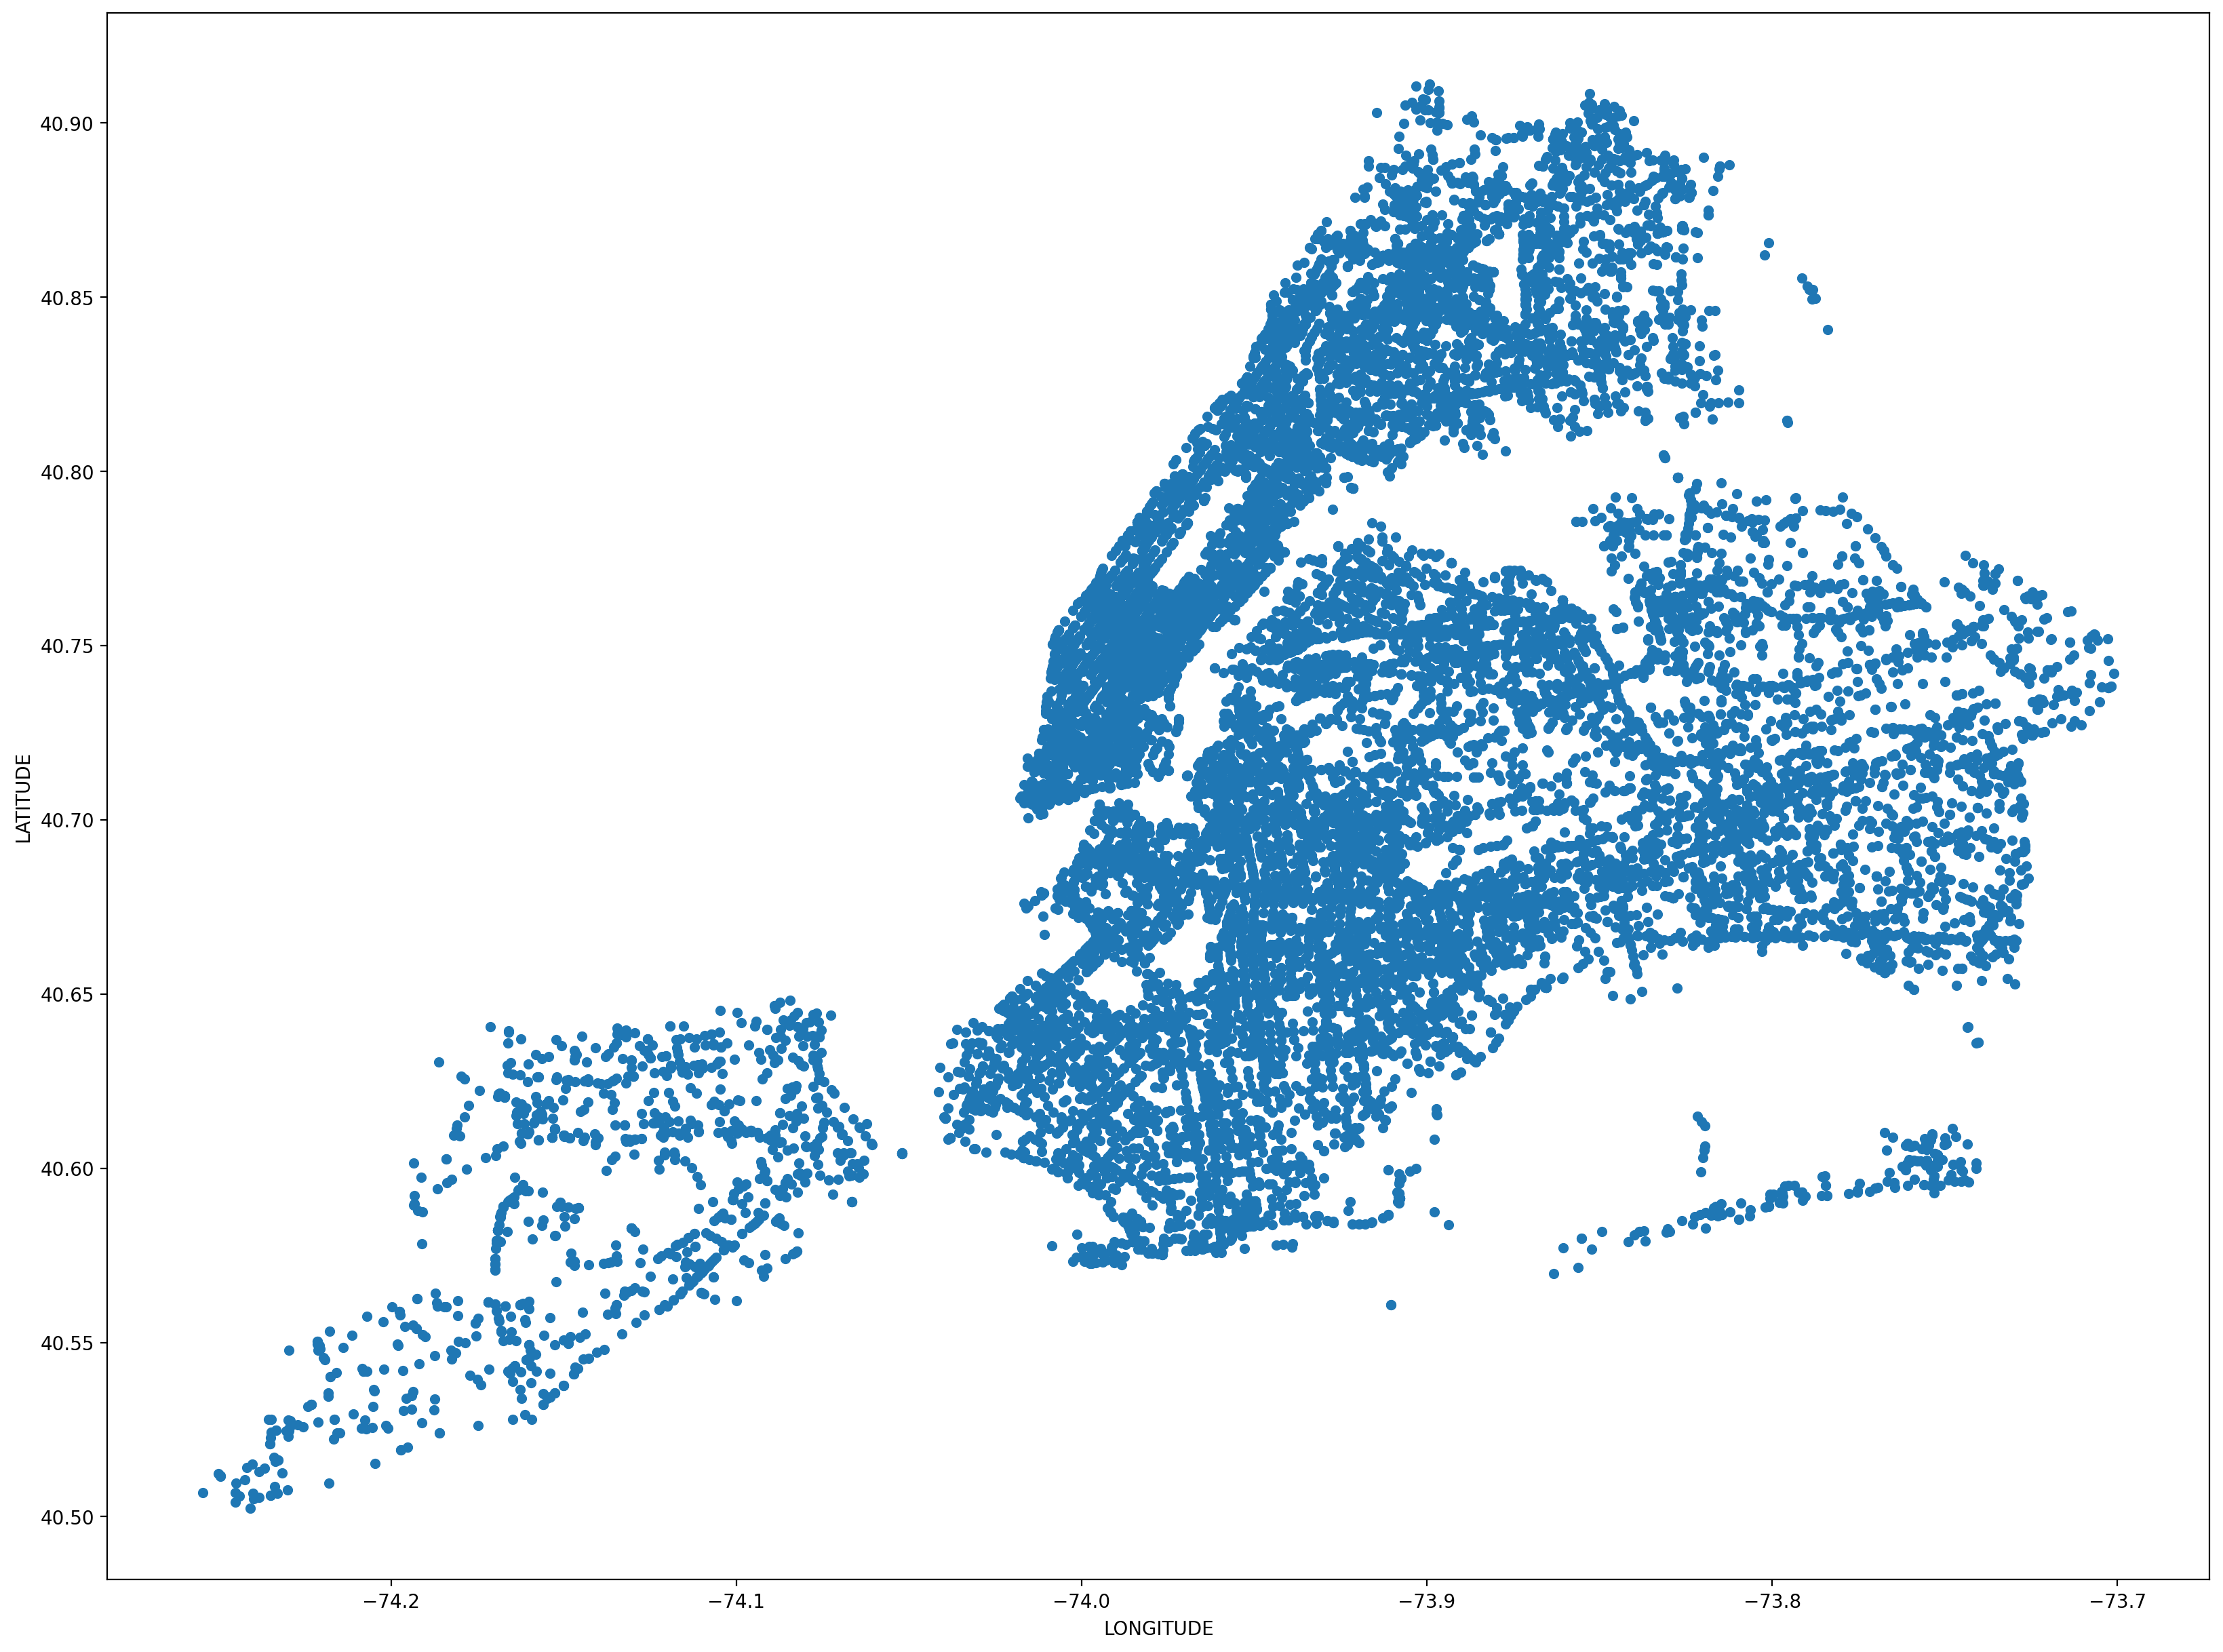

In [17]:
# We can either specify the number of data points,
# or the percentage of the dataset that we want to keep.

# Keep 10,000 data points
# sample = cleandf.sample(n=10000)

# Keep 1% of the dataset
sample = cleandf.sample(frac=0.01)

sample.plot(kind='scatter', x='LONGITUDE', y='LATITUDE', figsize=(20, 15))

### Changing marker size

Another technique that we can use is to reduce the market size. By default, in Pandas, the marker size for scatterplots is 5 pixels. We can reduce it to 1 pixel by setting `s=1`, or even smaller, eg., `s=0.5`. With this setting, we start seeting that there is a higher density of accidents among major highways.

<Axes: xlabel='LONGITUDE', ylabel='LATITUDE'>

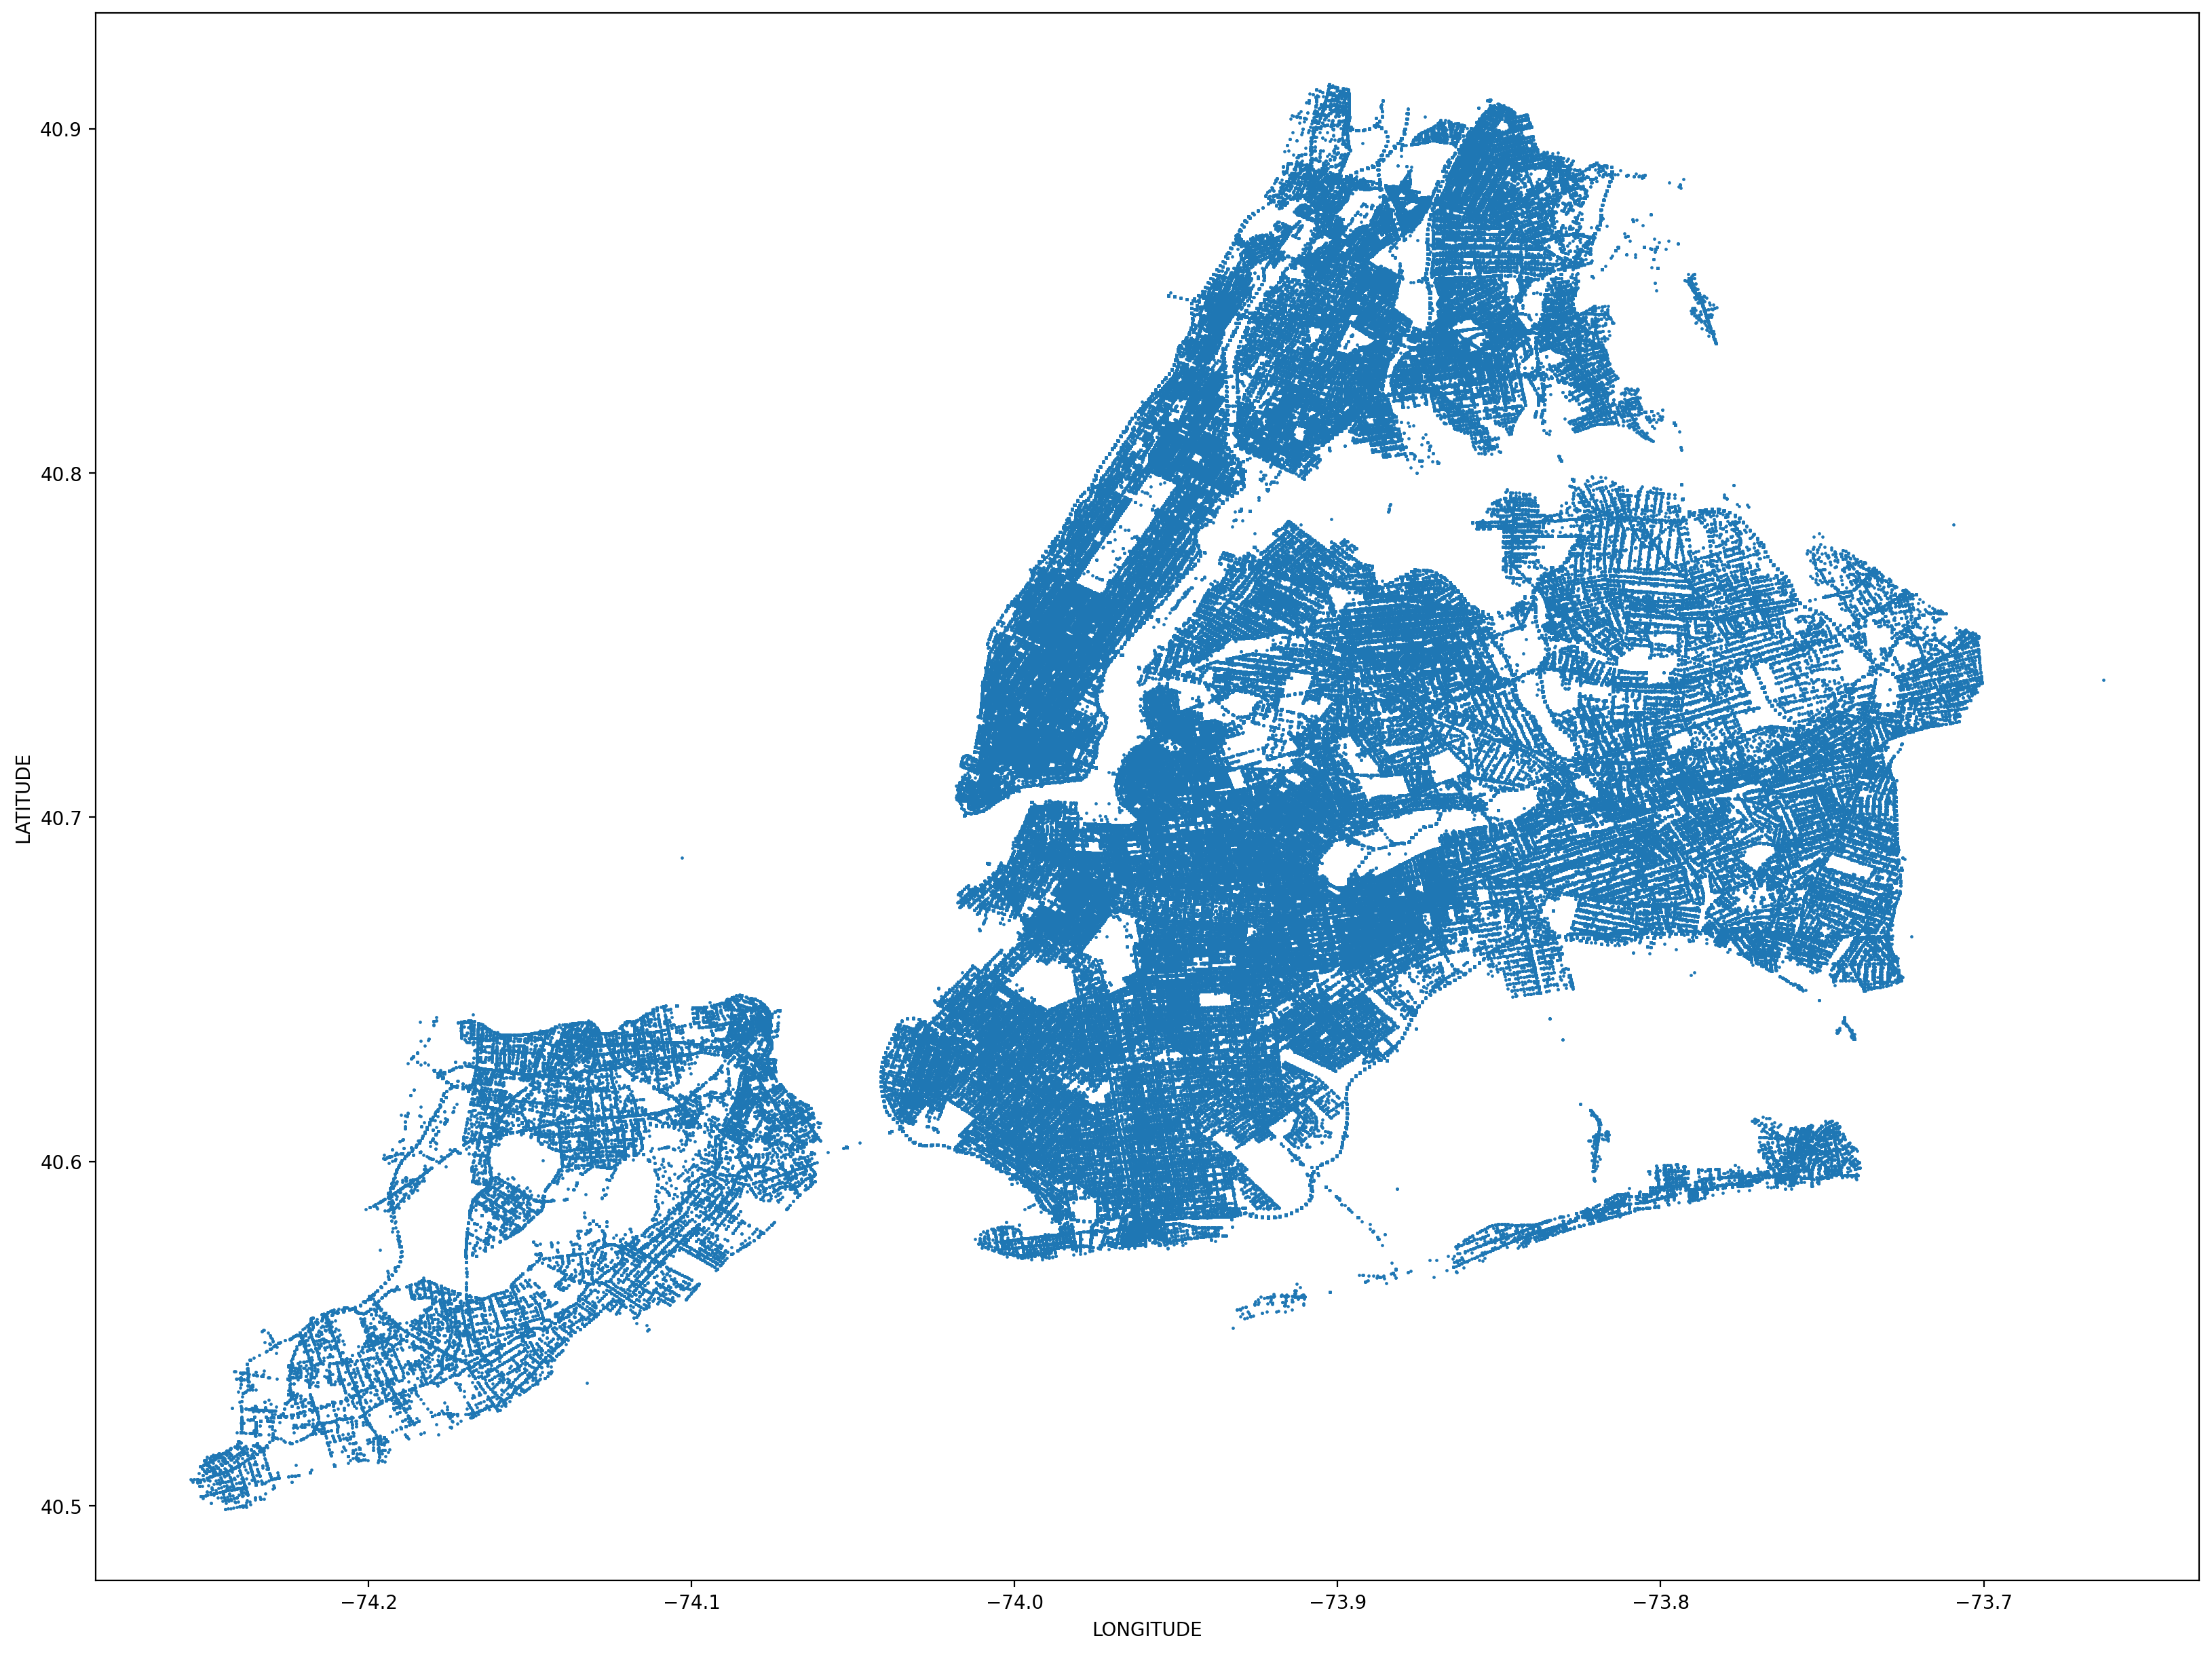

In [18]:
cleandf.plot(
    kind='scatter', x='LONGITUDE', y='LATITUDE', figsize=(20, 15), s=0.5 )

### Changing Marker Transparency

Another common technique is to change the  transparency of the  markers. Using semi-transparent markers we can then optically separate areas where there are many points (the area will still look densely plotted), from areas where there are only a few markers. We can set the transparency using the `alpha` parameter. Setting `alpha=1` means no transparency, while `alpha=0` is full transparency.

In [19]:
cleandf.plot(
    kind='scatter',
    x='LONGITUDE',
    y='LATITUDE',
    figsize=(20, 15),
    s=0.5,
    alpha=0.05)

Output hidden; open in https://colab.research.google.com to view.

### Creating 2d histograms, density plots, and contour plots


In the picture above, we can visually see that Manhattan, especially eastern midtown, and the area downtown near the entrance to the bridges, has a higher density. We can actually directly histograms and density plots on 2-dimensions.

#### Hexagonal bin plot



The hexbin plot created a 2-d histogram, where the color signals the number of points within a particular area. The `gridsize` parameter chooses the size of each bin. Higher values offer higher granularity, but very high values tend to create sparsity, when we do not have enough data points.

<Axes: xlabel='LONGITUDE', ylabel='LATITUDE'>

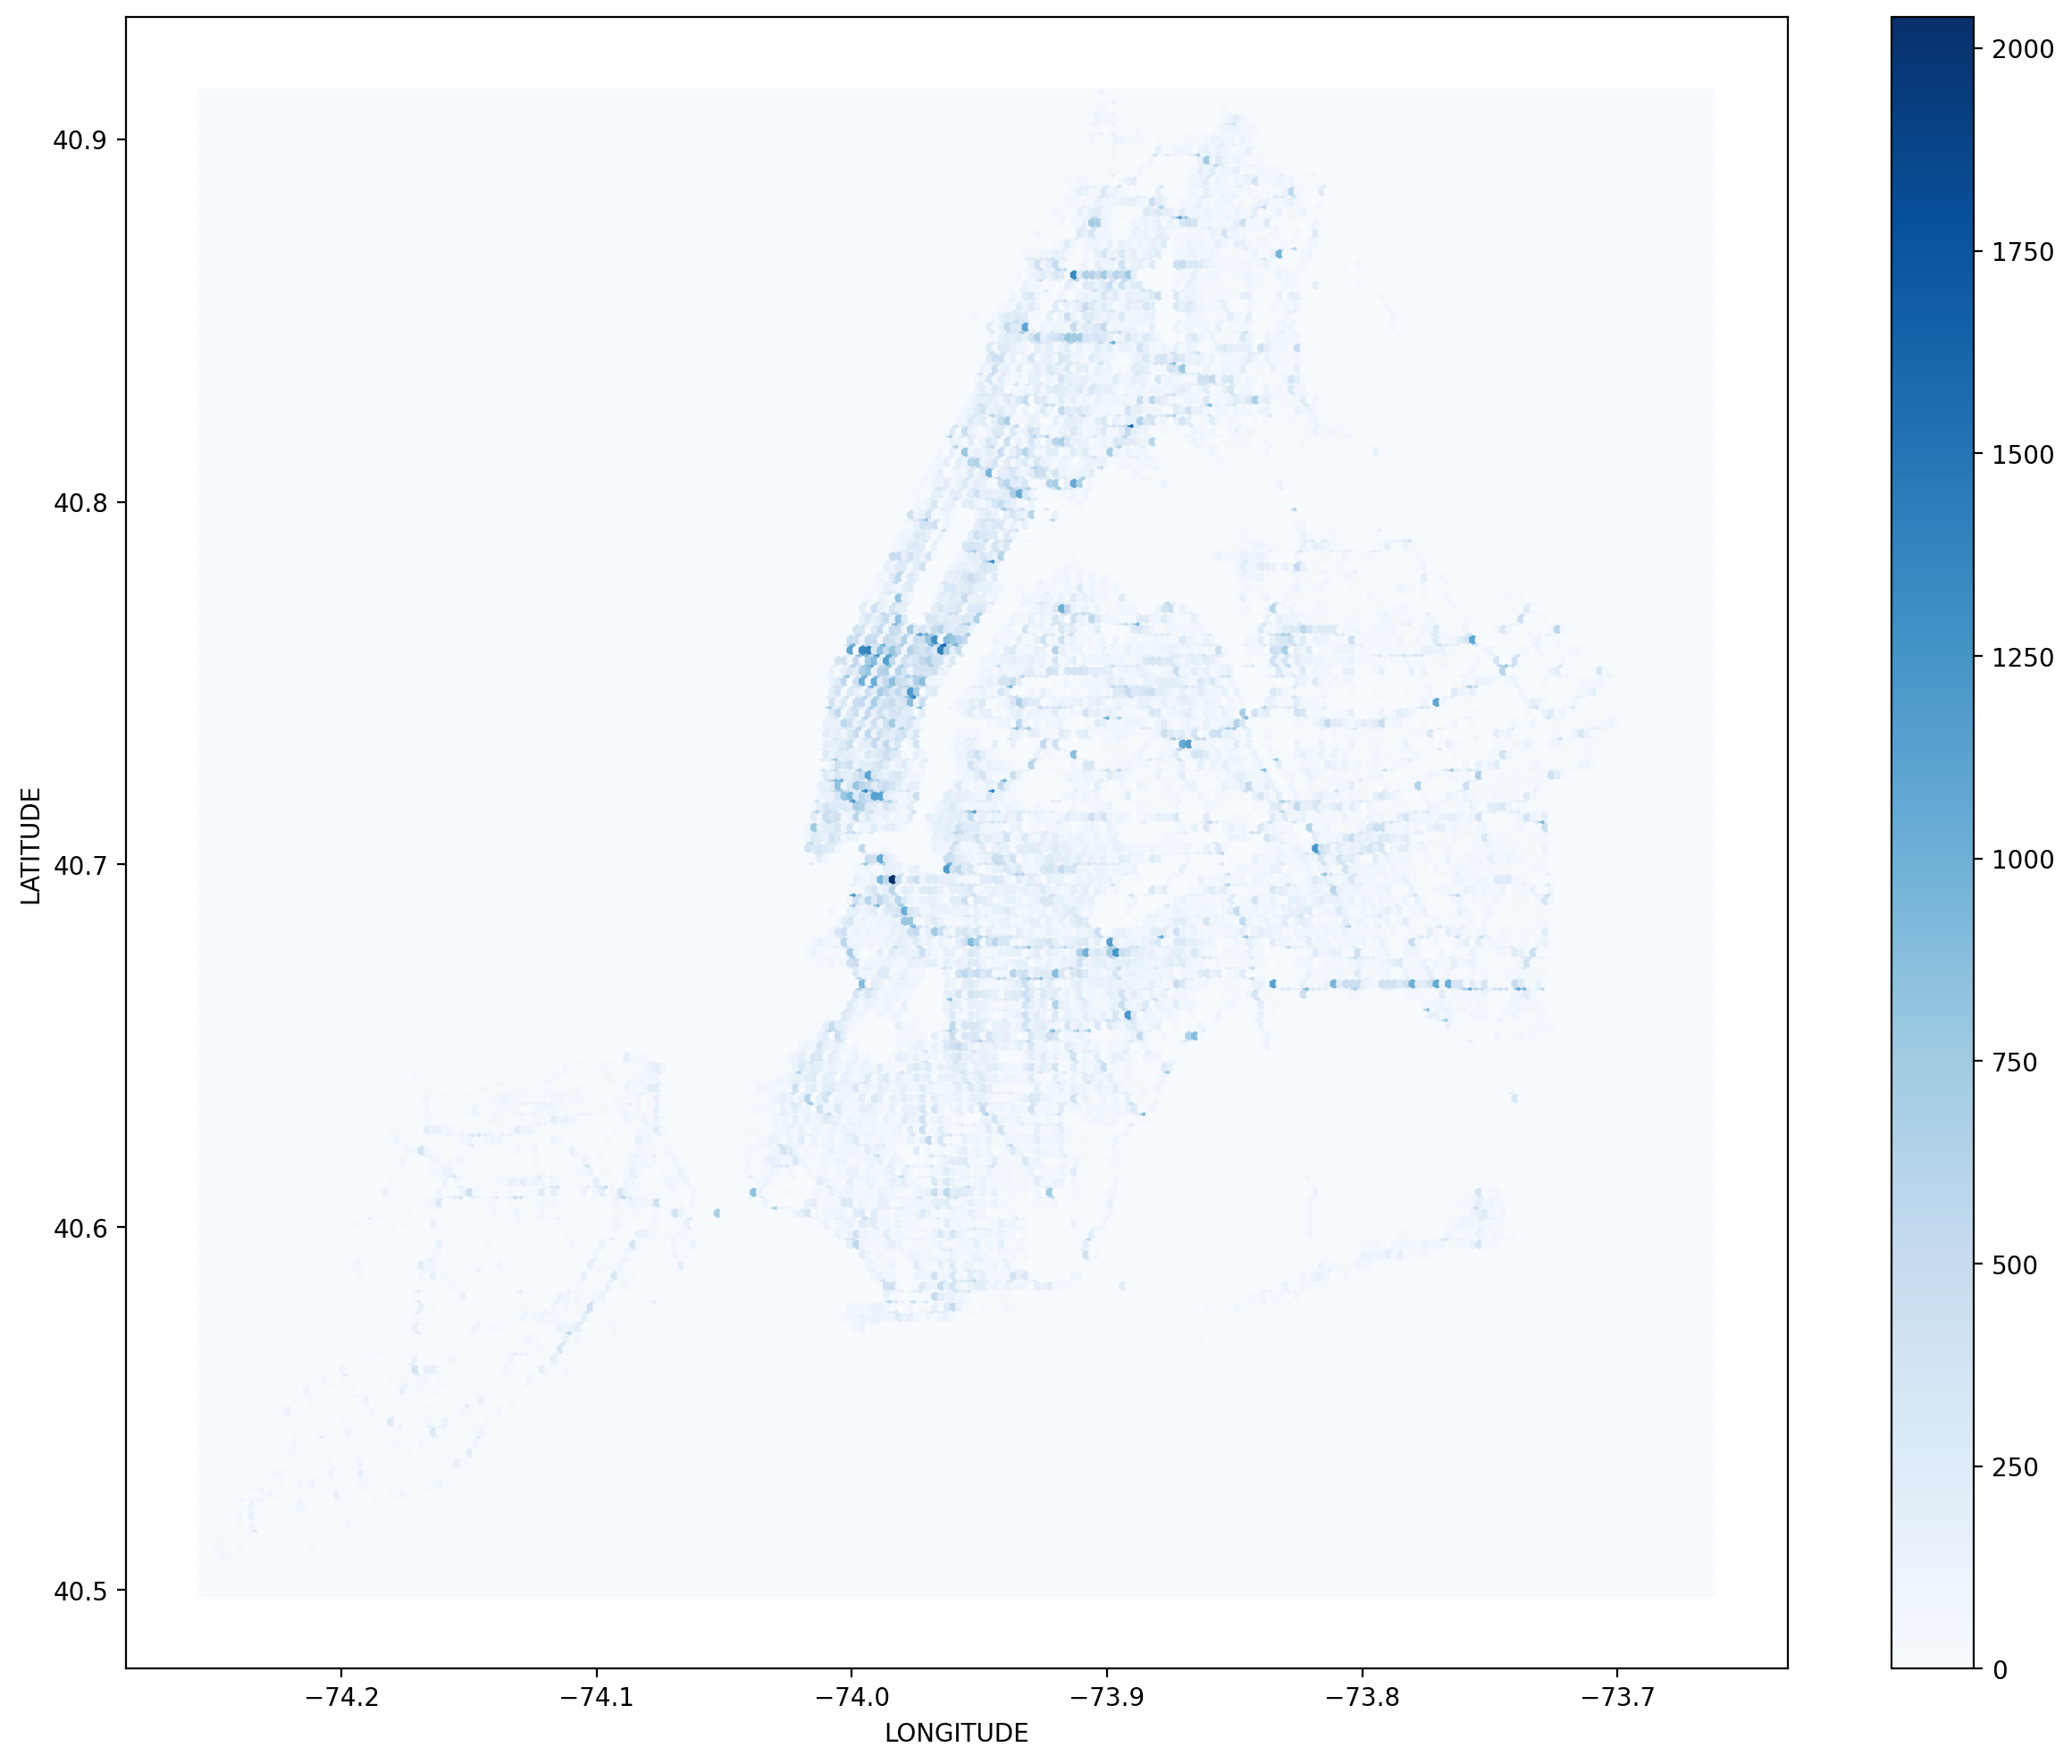

In [20]:
# Hexbin plot
cleandf.plot(
    kind='hexbin',
    x='LONGITUDE',
    y='LATITUDE',
    gridsize=250,
    cmap=plt.cm.Blues,
    figsize=(15, 12))

## Histograms


### Task 2:

Find out the most common contributing factors to the collisions.


In [21]:
df['CONTRIBUTING FACTOR VEHICLE 1'].value_counts()

,count
CONTRIBUTING FACTOR VEHICLE 1,
Unspecified,740810
Driver Inattention/Distraction,448423
Failure to Yield Right-of-Way,132371
Following Too Closely,118764
Backing Unsafely,80792
...,...
Windshield Inadequate,88
Cell Phone (hand-held),79
Texting,57


#### Solution

<Axes: ylabel='CONTRIBUTING FACTOR VEHICLE 1'>

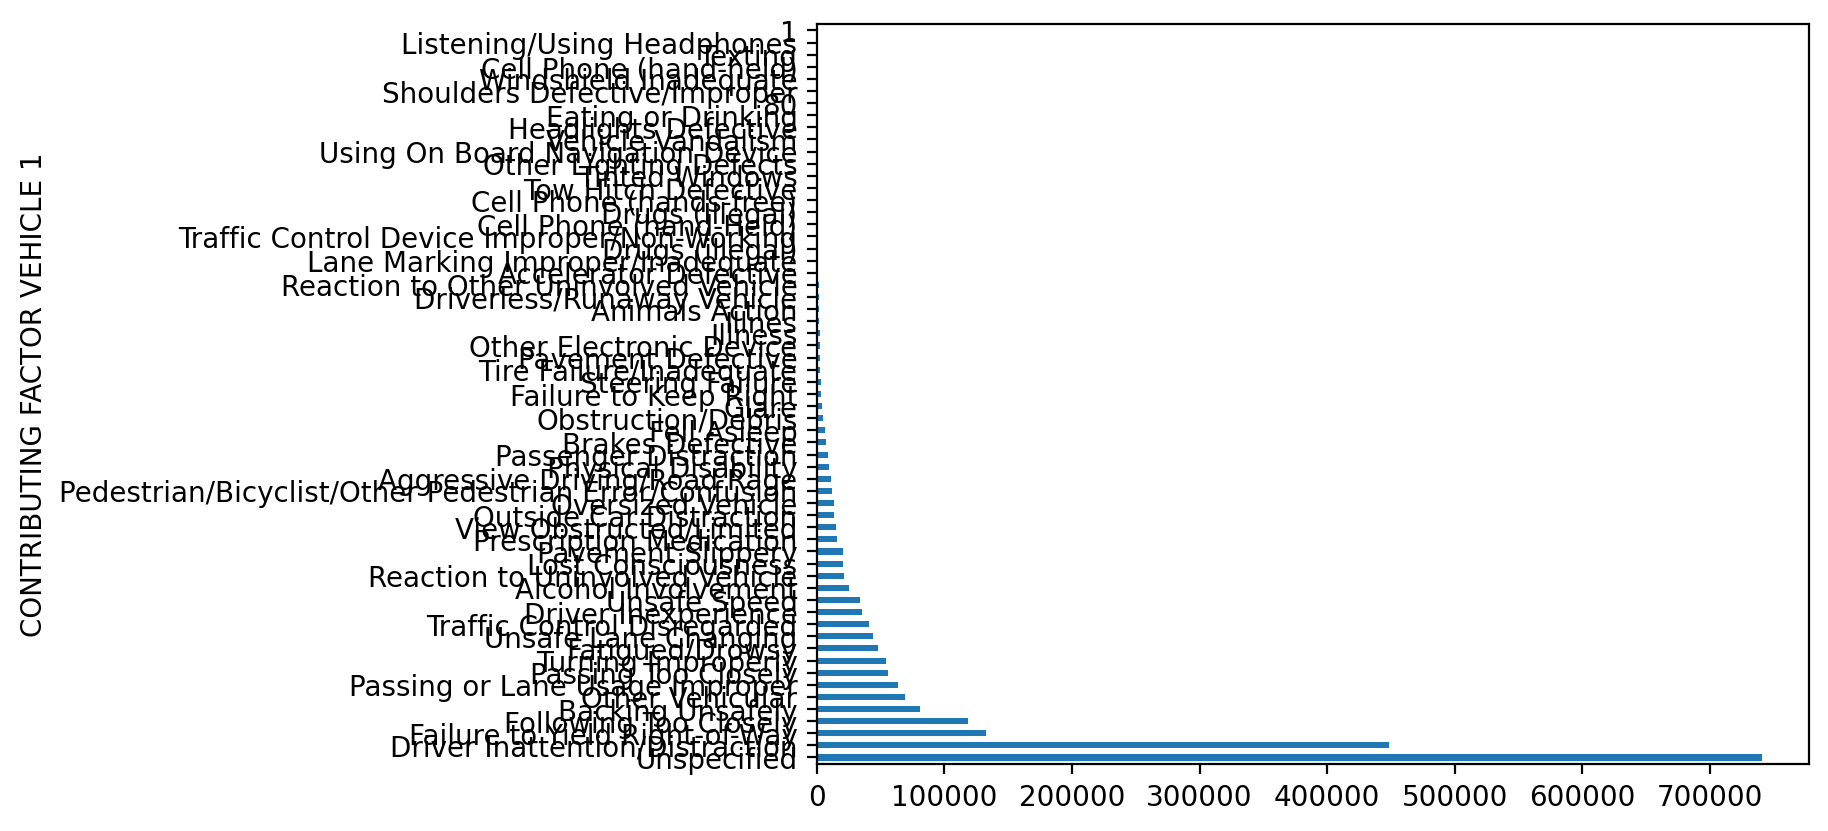

In [22]:
# Task 2: Find out the most common contributing factors to the collisions.
df['CONTRIBUTING FACTOR VEHICLE 1'].value_counts().plot(kind='barh')

<Axes: ylabel='CONTRIBUTING FACTOR VEHICLE 1'>

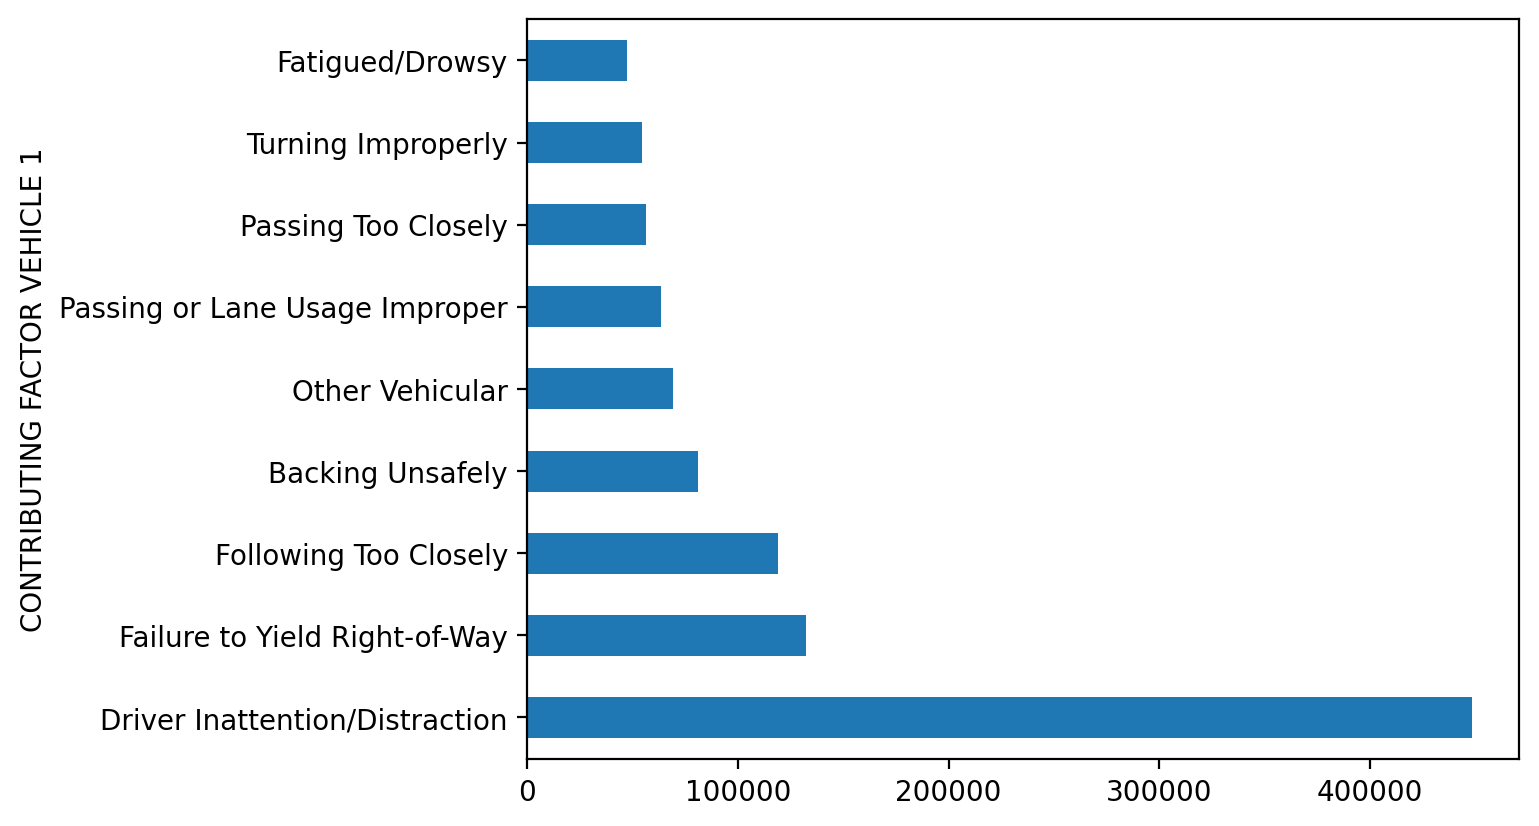

In [23]:
# Task 2: If we want to remove the "Unspecified", we select the elements starting
# from position 1 (i.e., the second element in the list, the first one is 0)
df['CONTRIBUTING FACTOR VEHICLE 1'].value_counts()[1:10].plot(kind='barh')

### Task 3:

Break down the number of collisions by borough.





#### Solution

<Axes: ylabel='BOROUGH'>

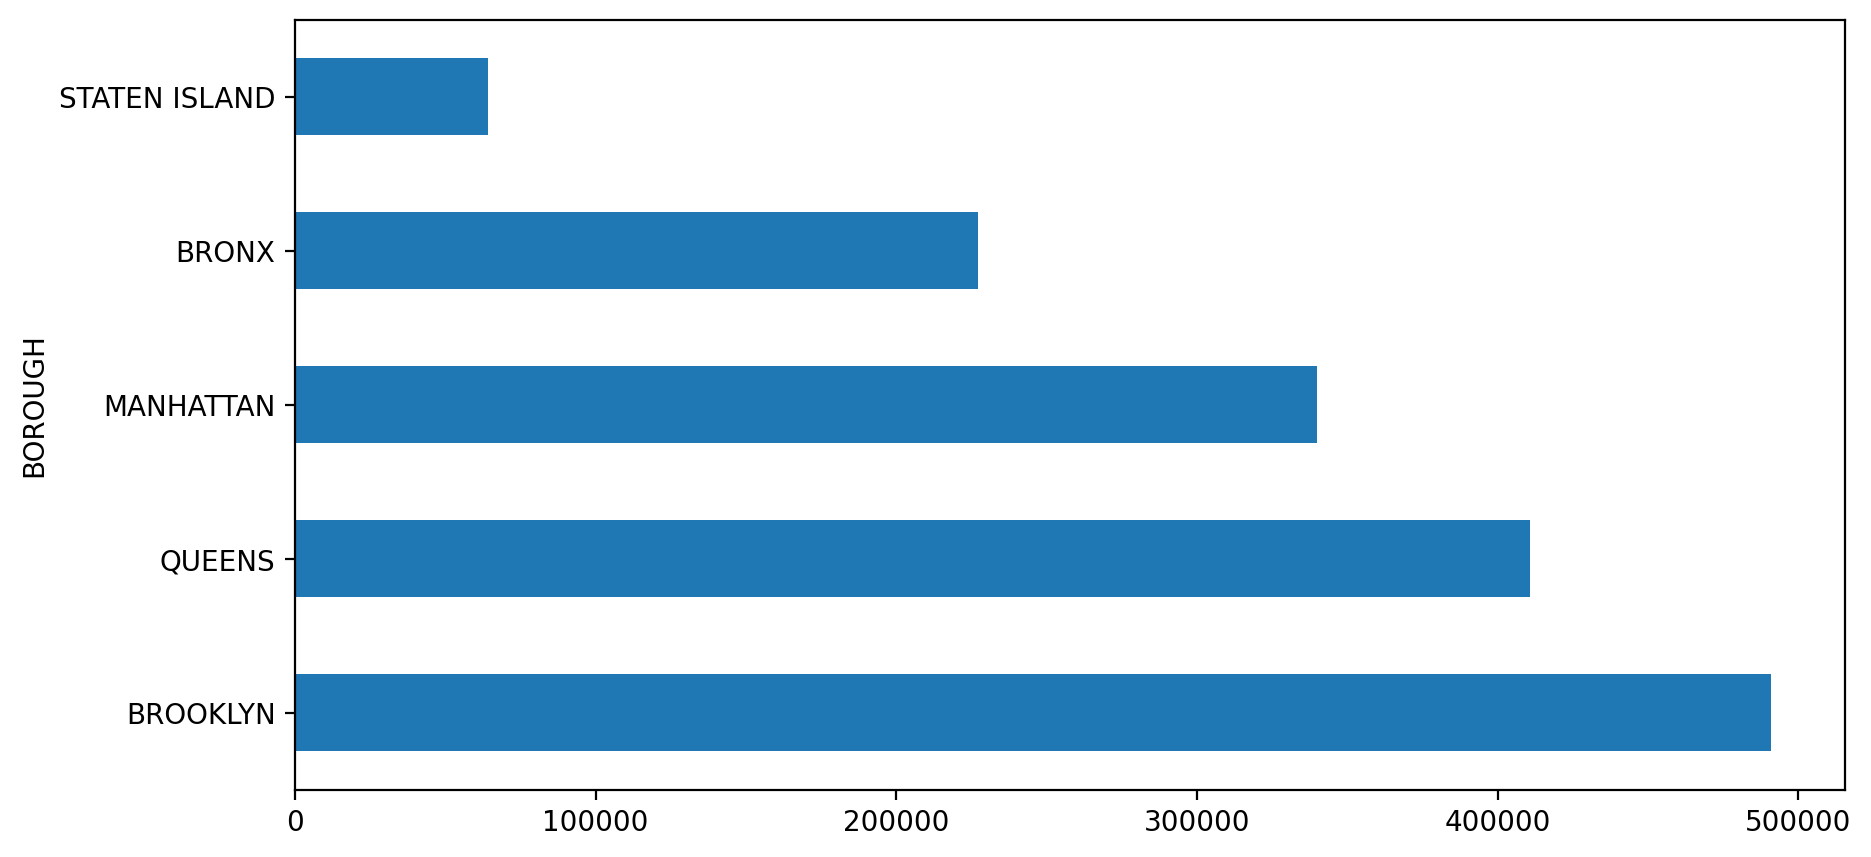

In [24]:
# Task 3: Break down the number of collisions by borough.
df['BOROUGH'].value_counts().plot(kind='barh', figsize=(10,5))

### Task 4

Find out the how many collisions had 0 persons injured, 1 persons injured, etc. persons injured in each accident. Use the `value_counts()` approach. You may also find the `.plot(logy=True)` option useful when you create the plot to make the y-axis logarigthmic.


#### Solution

Text(0.5, 1.0, 'Analysis of number of injuries per collision')

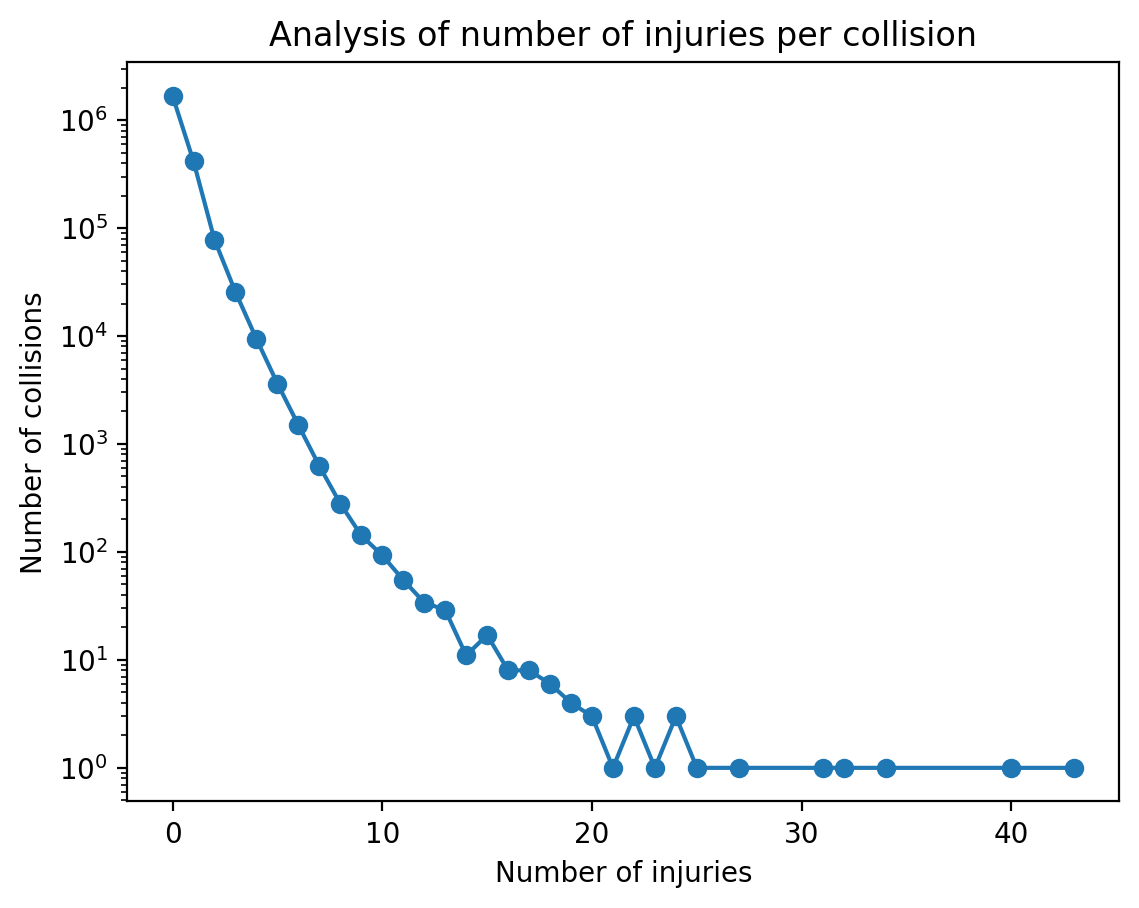

In [25]:
# "Chain" style of writing data maniputation operations
plot = (
    df['NUMBER OF PERSONS INJURED'] # take the num of injuries column
    .value_counts() # compure the freuquency of each value
    .sort_index() # sort the results based on the index value instead of the frequency,
                  # which is the default for value_counts
    .plot( # and plot the results
        kind='line', # we use a line plot because the x-axis is numeric/continuous
        marker='o',  # we use a marker to mark where we have data points
        logy=True # make the y-axis logarithmic
    )
)
plot.set_xlabel("Number of injuries")
plot.set_ylabel("Number of collisions")
plot.set_title("Analysis of number of injuries per collision")

### Task 5

(a) Compute the average number of injuries and deaths per accident, broken down by borough. Use the `pivot_table` functionality, putting `BOROUGH` as the index. You can answer this query by generating two separate tables, or you can create a single table by using the fact that you can pass a list of attributes/columns to the `values` parameter of the pivot table.

(b) Repeat the exercise above, but break down the average number of deaths and injuries using the contributing factor for the accident. Use the `sort_values` command to sort the results, putting on top the contributing factors that generate the highest number of deaths.

#### Solution

In [26]:
pd.pivot_table(
    data = df,
    index = 'BOROUGH',
    aggfunc = 'mean',
    values = ['NUMBER OF PERSONS INJURED', 'NUMBER OF PERSONS KILLED']
)

,NUMBER OF PERSONS INJURED,NUMBER OF PERSONS KILLED
BOROUGH,,
BRONX,0.346238,0.001379
BROOKLYN,0.349393,0.001460
MANHATTAN,0.226688,0.001112
QUEENS,0.317338,0.001424
STATEN ISLAND,0.300414,0.001651


In [27]:
pd.pivot_table(
    data = df,
    index = 'CONTRIBUTING FACTOR VEHICLE 1',
    aggfunc = 'mean',
    values = ['NUMBER OF PERSONS INJURED', 'NUMBER OF PERSONS KILLED']
).sort_values('NUMBER OF PERSONS KILLED', ascending=False)

,NUMBER OF PERSONS INJURED,NUMBER OF PERSONS KILLED
CONTRIBUTING FACTOR VEHICLE 1,,
Illnes,0.921284,0.030036
Tinted Windows,0.550725,0.014493
Unsafe Speed,0.699119,0.013289
Pedestrian/Bicyclist/Other Pedestrian Error/Confusion,0.805720,0.009214
Drugs (illegal),0.734375,0.008333
...,...,...
Texting,0.298246,0.000000
Traffic Control Device Improper/Non-Working,0.621885,0.000000
Using On Board Navigation Device,0.439024,0.000000


### Task 6

Break down the accidents by borough and contributing factor. Use the `pivot_table` function of Pandas


#### Solution

In [28]:
pivot = pd.pivot_table(
    data = df, # we analyze the df (accidents) dataframe
    index = 'CONTRIBUTING FACTOR VEHICLE 1',
    columns = 'BOROUGH',
    values = 'COLLISION_ID',
    aggfunc = 'count'
)

# Create an extra column showing the total deaths across boroughs (=columns)
pivot["Total"] = pivot.sum(axis="columns")

# Sort the dataframe by descending order of the values in the column "Total"
pivot = pivot.sort_values("Total", ascending=False)

pivot

BOROUGH,BRONX,BROOKLYN,MANHATTAN,QUEENS,STATEN ISLAND,Total
CONTRIBUTING FACTOR VEHICLE 1,,,,,,
Unspecified,92592.0,201936.0,106546.0,140379.0,24329.0,565782.0
Driver Inattention/Distraction,37501.0,87313.0,72808.0,89005.0,13192.0,299819.0
Failure to Yield Right-of-Way,10728.0,31766.0,16245.0,35440.0,4077.0,98256.0
Backing Unsafely,9602.0,19250.0,12329.0,19883.0,2774.0,63838.0
Following Too Closely,7010.0,16026.0,11432.0,15154.0,2376.0,51998.0
...,...,...,...,...,...,...
Cell Phone (hand-held),8.0,21.0,15.0,11.0,1.0,56.0
Shoulders Defective/Improper,13.0,10.0,15.0,15.0,3.0,56.0
Texting,5.0,7.0,7.0,8.0,6.0,33.0


### Task 7

Find the dates with the most accidents. Can you figure out what happened on these days?


#### Solution

In [29]:
df["CRASH DATE"].value_counts()

,count
CRASH DATE,
2014-01-21,1161
2018-11-15,1065
2017-12-15,999
2017-05-19,974
2015-01-18,961
...,...
2020-04-23,108
2020-04-12,106
2020-04-09,103


### Task 8

Plot the number of accidents per day. (Hint: Ensure that your date column is in the right datatype and that it is properly sorted, before plotting)


#### Solution

In [30]:
df["CRASH DATE"] = pd.to_datetime(df["CRASH DATE"], format="%m/%d/%Y", errors="coerce")

<Axes: xlabel='CRASH DATE'>

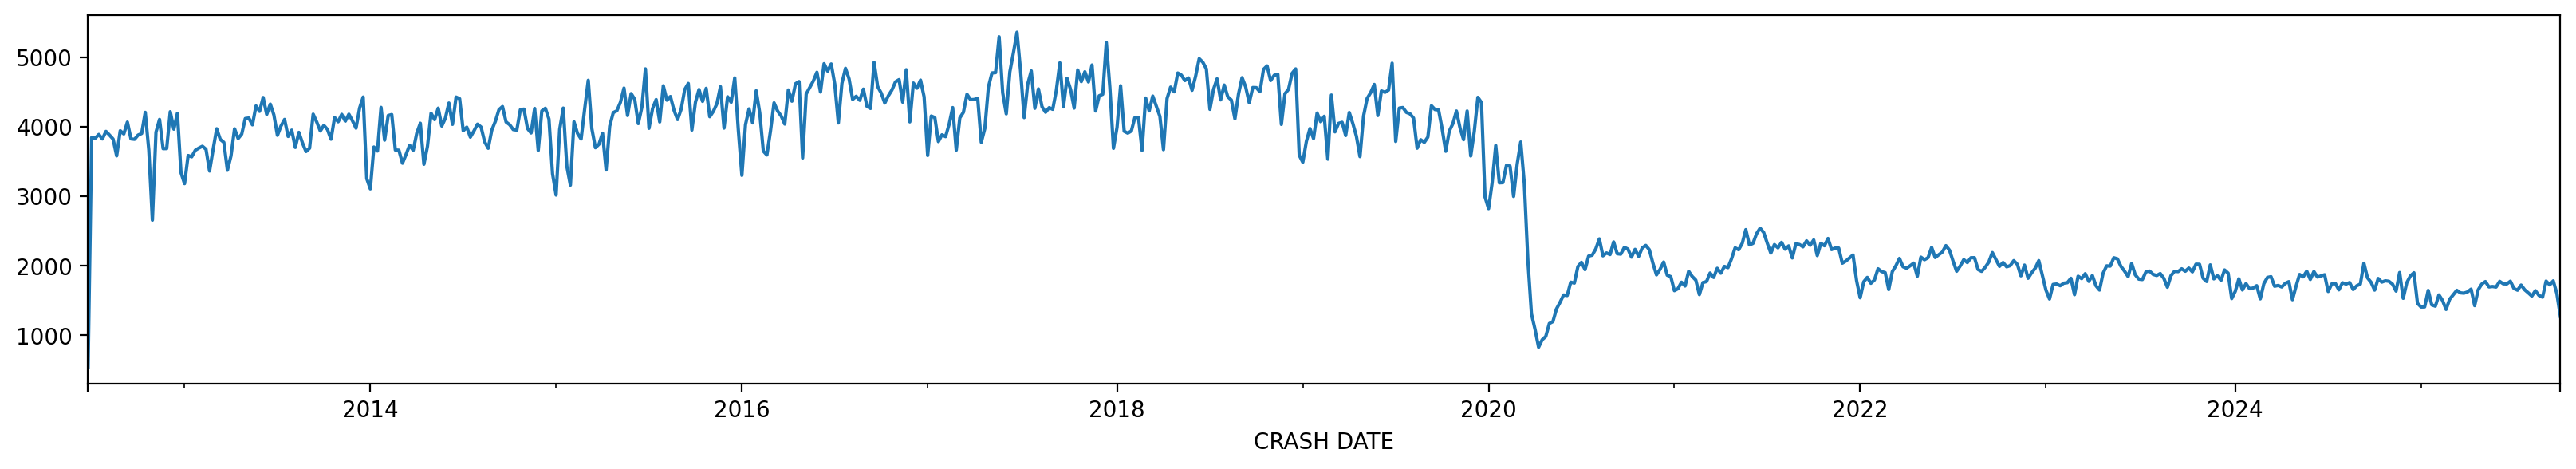

In [31]:
(
    df["CRASH DATE"].value_counts() # count the number of accidents per day
    .sort_index() # sort the dates
    .resample('1W') # take periods of 1 month
    .sum() # sum the number of accidents per month
    .plot(figsize=(20,3)) # plot the result
)

/tmp/ipython-input-1477920617.py:9: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample('1M') # take periods of 1 month


<Axes: xlabel='CRASH DATE'>

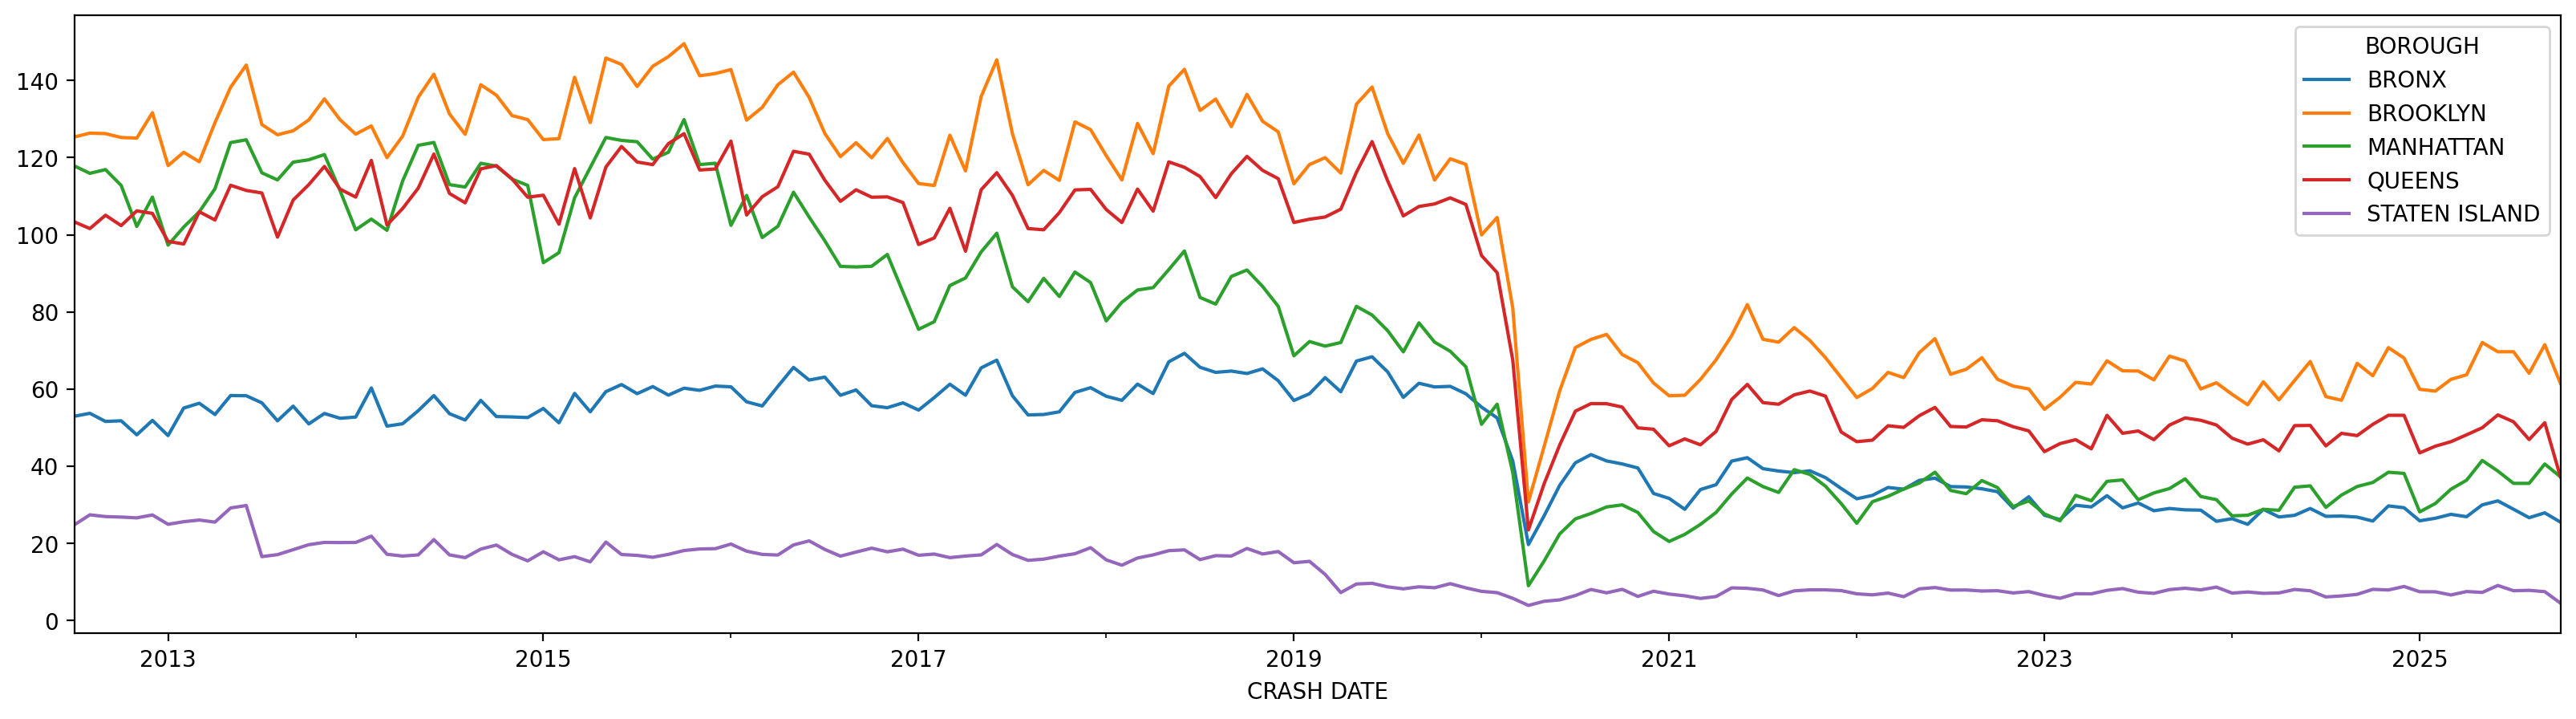

In [32]:
(
    pd.pivot_table(
      data = df,
      index = "CRASH DATE",
      columns = "BOROUGH",
      values = "COLLISION_ID",
      aggfunc = "count"
    )
    .resample('1M') # take periods of 1 month
    .mean() # avg number of accidents per month
    .plot(figsize=(20,5)) # plot the result
)

### Task 9

We want to analyze the timing patterns of accidents that lead to death or injury.

We will do the analysis by creating histograms showing the frequency of deadly vs non-deadly accidents throughout the day. By comparing the two histograms we will be able to understand if time of day is correlated with deadly accidents or not.

Steps to follow:
* Ensure that the `CRASH TIME` column is converted to a datetime. The format is HH:MM, which can be written as `format="%H:%M"` in the `to_datetime` command of Pandas.
* Create a boolean column `DEATH` that is true when someone was killed in the accident (i.e., `NUMBER OF PERSONS KILLED > 0`).
* Create a boolean column `INJURY` that is true when someone was injured in the accident (i.e., `NUMBER OF PERSONS INJURED > 0`).
* Query the dataframe to get back the deadly accidents and create a histogram of deadly accidents over time. Do the same for non-deadly accidents.
* To allow a more direct visual comparison of the two histograms, we want to merge them in one plot. Since the number of accidents without deaths is *much* higher, we want the histograms to be normalized (i.e., `density=True`).
* It is also a good idea to make the histographs partially transparent, to allow for easier comparison of the two histograms.


### Solution

In [33]:
# Define the indicator variables
df['INJURY'] = (df['NUMBER OF PERSONS INJURED']>0)
df['DEATH'] = (df['NUMBER OF PERSONS KILLED']>0)

df['CRASH TIME'] = pd.to_datetime(df['CRASH TIME'], format="%H:%M")

In [34]:
# Define the two subsets
deadly_accidents = df[ df['DEATH'] == True ]
noharm_accidents = df[ df['DEATH'] == False ]

<Axes: >

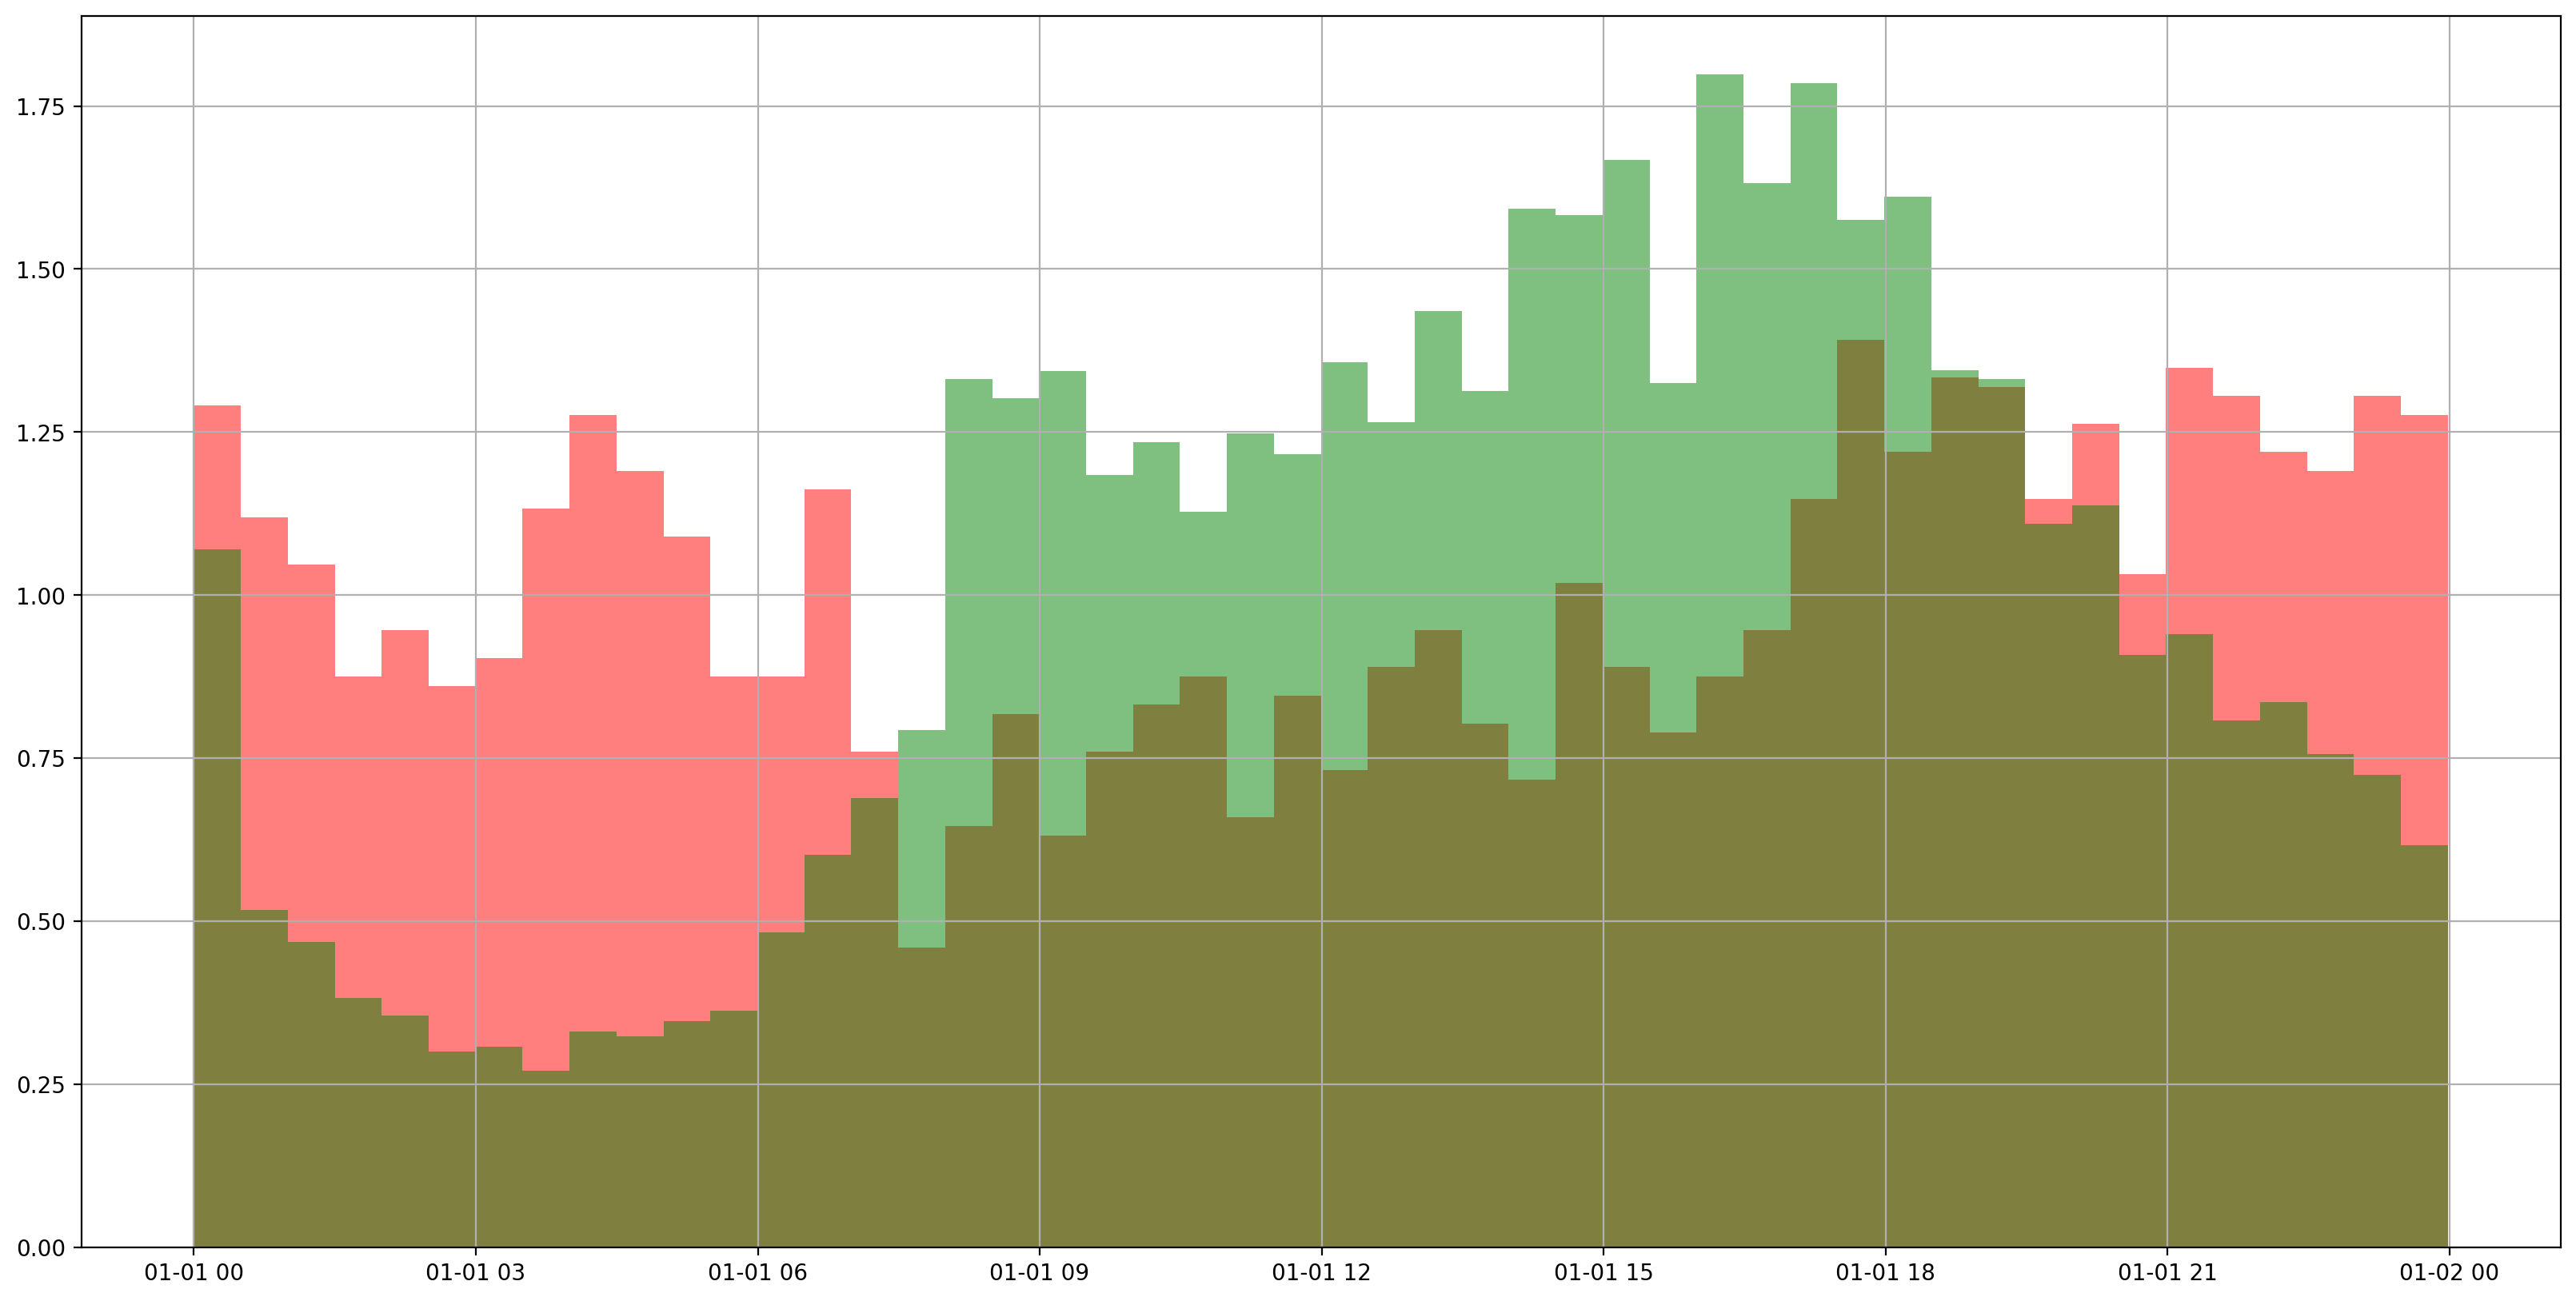

In [35]:
deadly_accidents['CRASH TIME'].hist(
    bins=48, # one bar per half hour
    figsize=(20,10),  # make the figure bigger
    density=True, # normalize the counts
    alpha=0.5,  # make the histogram semi-transparent
    color='red' # color red the deadly accidents
)

noharm_accidents['CRASH TIME'].hist(
    bins=48,
    figsize=(20,10),
    density=True,
    alpha=0.5,
    color='green'
)

In [36]:
injuries = df[ df['INJURY'] == True ]
no_injuries = df[ df['INJURY'] == False ]

<Axes: >

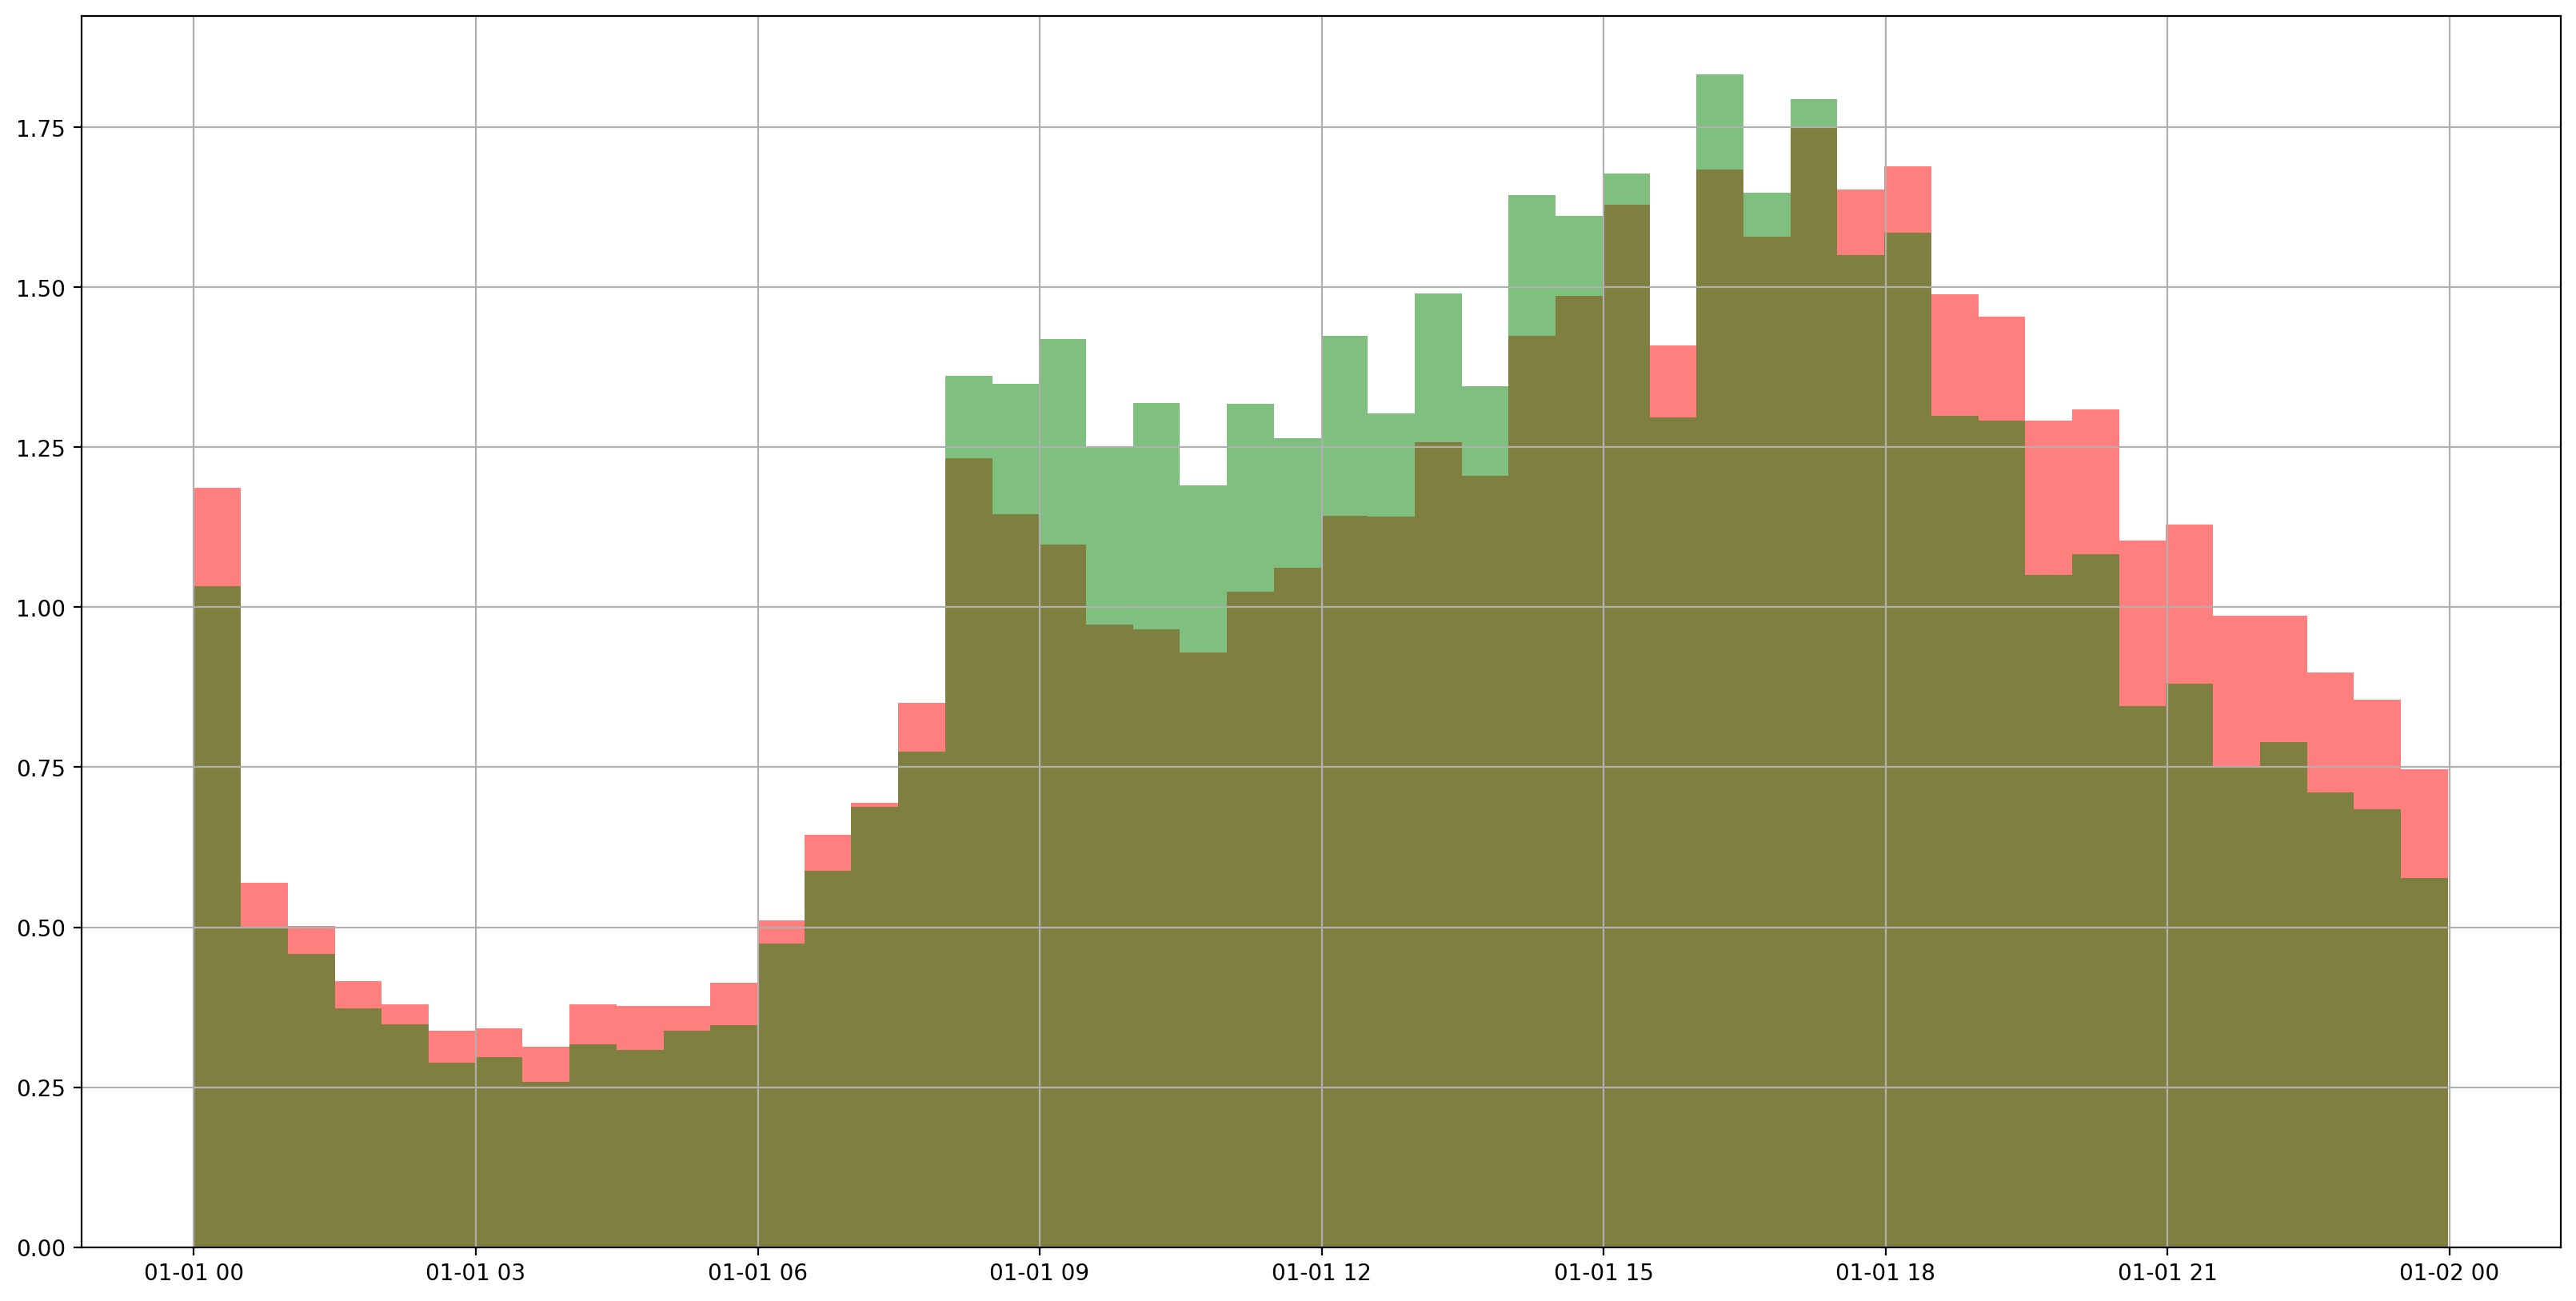

In [37]:
injuries['CRASH TIME'].hist(bins=48,figsize=(20,10), density=True,alpha=0.5, color='red')
no_injuries['CRASH TIME'].hist(bins=48,figsize=(20,10), density=True,alpha=0.5, color='green')

<Axes: >

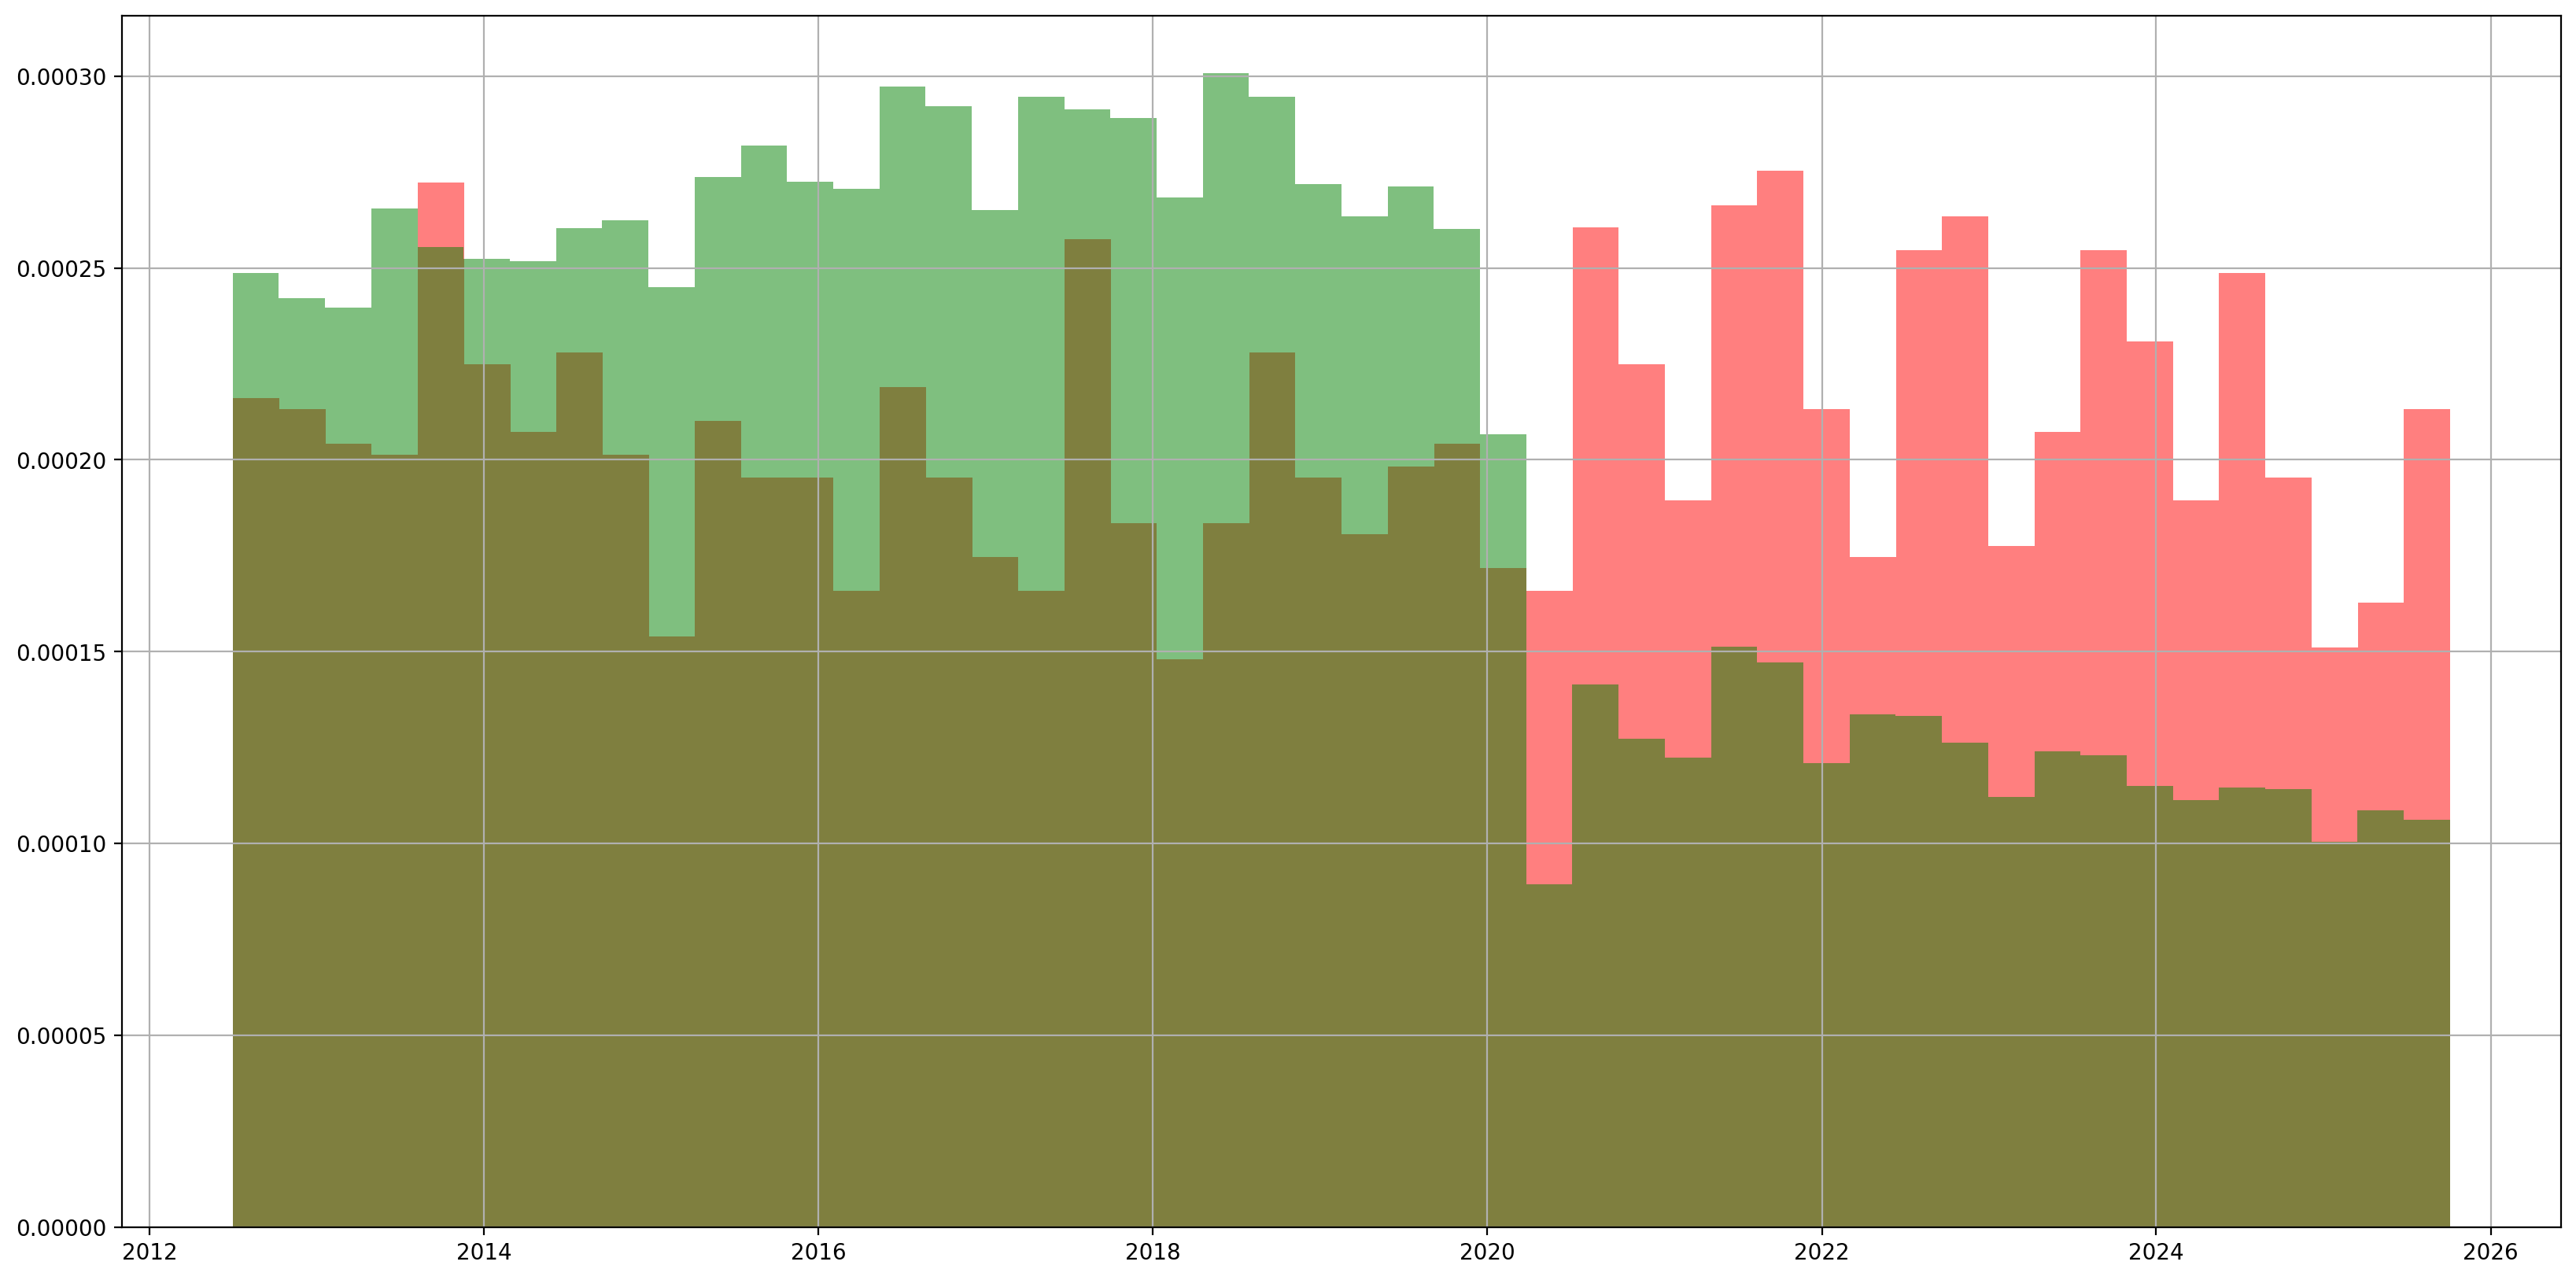

In [38]:
deadly_accidents['CRASH DATE'].hist(bins=48,figsize=(20,10), density=True,alpha=0.5, color='red')
noharm_accidents['CRASH DATE'].hist(bins=48,figsize=(20,10), density=True,alpha=0.5, color='green')

<Axes: >

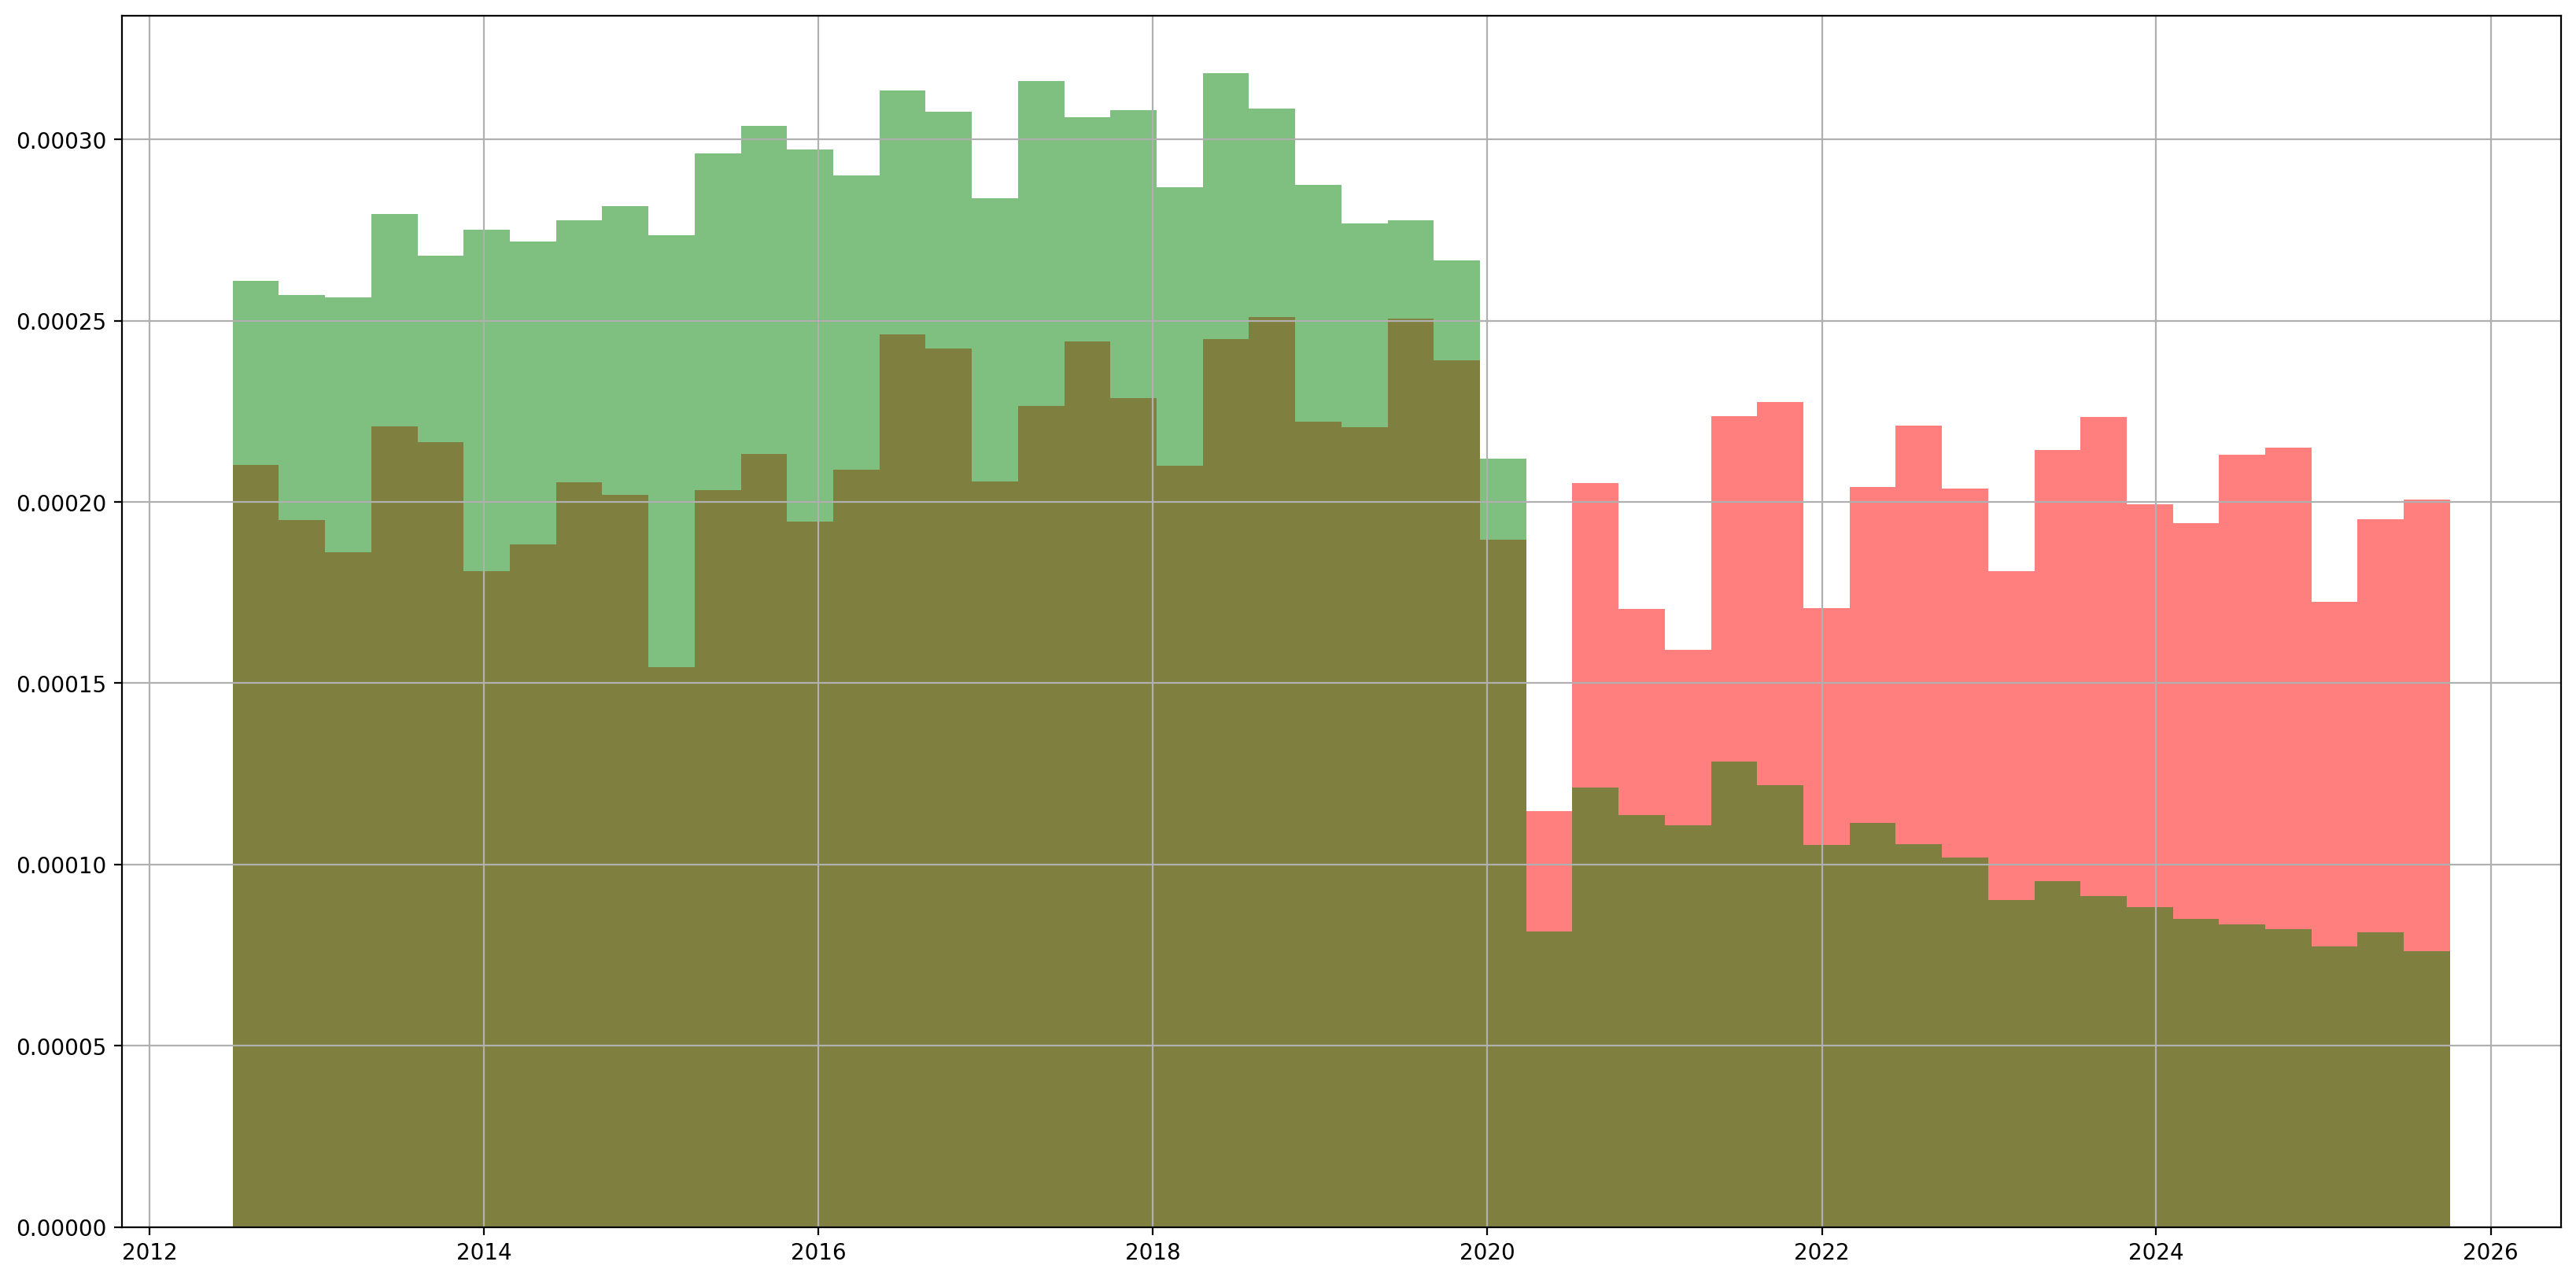

In [39]:
injuries['CRASH DATE'].hist(bins=48,figsize=(20,10), density=True,alpha=0.5, color='red')
no_injuries['CRASH DATE'].hist(bins=48,figsize=(20,10), density=True,alpha=0.5, color='green')